### **라이브러리 로드**

In [1]:
# 데이터 처리
import pandas as pd
import numpy as np
from IPython.display import display

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# 통계 검정
import scipy
from scipy.stats import chi2_contingency  # 카이제곱 검정
from scipy.stats import spearmanr         # 스피어만 상관계수
from scipy.stats import PermutationMethod # Monte Carlo 시뮬레이션
from scipy.stats import fisher_exact # Fisher's exact

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 데이터프레임 출력 제한 해제
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

---
### **데이터 로드**

In [2]:
# FnB 롱폼에서 성공으로 분류된 영상 분류 결과
df_success_video = pd.read_csv("../../../data/results/main_dataset/롱폼 영상(+콘텐츠 분류 정보)/fnb_longform_success_data_with_classified.csv", encoding='utf-8')

# FnB 롱폼에서 실패로 분류된 영상 분류 결과
df_fail_video = pd.read_csv("../../../data/results/main_dataset/롱폼 영상(+콘텐츠 분류 정보)/fnb_longform_fail_data_with_classified.csv", encoding='utf-8')

# FnB 롱폼에서 성공으로 분류된 영상의 댓글 감성 분석 결과
df_success_comment = pd.read_csv("../../../data/results/main_dataset/댓글(필터링+감성분석 정보)/sentiment_fnb_longform_success_comment_final.csv", encoding='utf-8')

# FnB 롱폼에서 실패으로 분류된 영상의 댓글 감성 분석 결과
df_fail_comment = pd.read_csv("../../../data/results/main_dataset/댓글(필터링+감성분석 정보)/sentiment_filtered_cleaned_fnb_longform_fail_comment.csv", encoding='utf-8')

In [3]:
# 데이터 로드 결과 확인
print("성공 영상 분류 결과:", df_success_video.columns.tolist())
print("실패 영상 분류 결과:", df_fail_video.columns.tolist())
print("성공 영상의 댓글 감성 분석 결과:", df_success_comment.columns.tolist())
print("실패 영상의 댓글 감성 분석 결과:", df_fail_comment.columns.tolist())

성공 영상 분류 결과: ['video_id', 'title', 'channel_id', '채널명', 'description', '업로드일시', 'tags', '조회수', '좋아요수', '댓글수', '영상길이(초)', 'definition', 'license', 'embeddable', 'has_paid_product_placement', 'thumbnail', 'caption', 'final_url', 'instream_type', 'channel_handle', 'channel_tier', '구독자수', 'domain', 'description_missing_flag', 'tags_missing_flag', '참여율(ER)', '조회수 대비 좋아요율', '조회수 대비 댓글률', 'wei', 'description_length', 'category_name', 'upload_year', 'upload_month', 'upload_dayofweek', 'upload_hour', 'tags_count', 'upload_quarter', 'upload_ym_quarter', 'upload_ymd', '경과일수', '도달률(RR)', '일평균 조회수', 'RR_백분위', 'ER_백분위', 'score1', '조회수성과', '좋아요성과', '댓글성과', '조회수성과_상위1%', '조회수성과_상위5%', '좋아요성과_상위1%', '좋아요성과_상위5%', '댓글성과_상위1%', '댓글성과_상위5%', 'score2', 'grade', 'cls_domain', 'cls_content_type', 'cls_marketing_purpose', 'cls_cta_type', 'cls_is_series', 'cls_is_collaboration', 'cls_reason']
실패 영상 분류 결과: ['video_id', 'title', 'channel_id', '채널명', 'description', '업로드일시', 'tags', '조회수', '좋아요수', '댓글수', '영상길이(초)'

In [4]:
# 데이터프레임 확인
display(df_success_video.head(1))
display(df_fail_video.head(1))
display(df_success_comment.head(1))
display(df_fail_comment.head(1))

,video_id,title,channel_id,채널명,description,업로드일시,tags,조회수,좋아요수,댓글수,영상길이(초),definition,license,embeddable,has_paid_product_placement,thumbnail,caption,final_url,instream_type,channel_handle,channel_tier,구독자수,domain,description_missing_flag,tags_missing_flag,참여율(ER),조회수 대비 좋아요율,조회수 대비 댓글률,wei,description_length,category_name,upload_year,upload_month,upload_dayofweek,upload_hour,tags_count,upload_quarter,upload_ym_quarter,upload_ymd,경과일수,도달률(RR),일평균 조회수,RR_백분위,ER_백분위,score1,조회수성과,좋아요성과,댓글성과,조회수성과_상위1%,조회수성과_상위5%,좋아요성과_상위1%,좋아요성과_상위5%,댓글성과_상위1%,댓글성과_상위5%,score2,grade,cls_domain,cls_content_type,cls_marketing_purpose,cls_cta_type,cls_is_series,cls_is_collaboration,cls_reason
0,0JTsvNMmMjs,"""이걸 셰프 앞에서?!"" 필터 없는 솔직 리뷰 😝 | [톡! 까놓고 신상리뷰💬]",UCsM07dUwo0WOWhFbVsG8K6A,CU [씨유튜브],"재업 🎥⚠️\n영상 오류로 인해 재업로드 했습니다!\n\n이전 영상에서 이벤트에 참여해주신 분들의 참여 내역은 \n모두 정상 확인 완료되었으니\n걱정하지 않으셔도 됩니다 🙏✨\n\n키친보스 김호윤 셰프 협업 상품부터\n2월 1주차 CU 신상 리뷰까지!\n\n배우 이송경 X 63만 유튜버 맛상무의\n톡 까놓고 편의점 신상 리뷰〈톡! 까놓고 신상리뷰〉\n\n📌 이번 주 리뷰 라인업\n키친보스 갓김치만두 3,200원\n키친보스 봄나물새우죽 3,200원\n연세 명장메론크림빵 3,500원\n스누피더블크림마카롱 3,600원\n스누피 떠먹는 페퍼로니 4,700원\n삼송 콘마요떡갈비고로케 4,500원\n라라스윗 소시지빵오리진 3700원\n빵잼빵베리더블샌드 1,900원\nCJ 흑백마라샹궈덮밥 5,900원\n\n💬댓글 #event 💬\n톡! 까놓고 신상리뷰 1화의 감상평을 남겨주세요\n추첨을 통해 선물을 드립니다.\n\n📌 이벤트 기간 : 2/2(목) ~ 2/9(목)\n📌 당첨자 발표 : 2/19(목) \n📌 이벤트 경품 : CU모바일상품권 5천원권(30명)\n\n🎉 [댓글 이벤트 당첨자 발표] 🎉 \n안녕하세요😊 이벤트에 참여해주신 모든 분들에게 감사드리며, 당첨자 발표하겠습니다! \n\n💝CU모바일 상품권 5천원권(30명) \n\n@겨울겨울-o8p\n@cheatkeys\n@naseongbeom78\n@젤라보\n@33giuri\n@사탕비가내려\n@gotuhome\n@HunnyBear390\n@luccy123\n@락스타냥\n@ole_ole_uu\n@최은이-k3n\n@manamo4367\n@naver_bond\n@otmealwetisu\n@지리산계곡물\n@용인시불가동\n@수정-i5q\n@미련여우탱이-o1q\n@소왓데이비스\n@oijisun\n@talia0fr\n@우인상점\n@vc3570\n@wpffl_\n@priderich1\n@Qleo\n@srpfaker\n@sorrjj\n@연듀-f3z\n\n당첨된 분은 2/26(목)까지 아래 URL로 경품 발송을 위한 정보 입력 부탁드립니다. \n경품 발송 정보가 전달되지 않을 시, 당첨은 자동으로 취소됩니다. \n경품 발송 정보 입력하기 ▶https://forms.gle/RPytHsqGHM9g1viw6\n\n#이벤트 #CU #씨유 #톡까놓고신상리뷰 #이송경 #맛상무 #키친보스\n#CU신상 #명장빵 #연세우유 #스누피 #라라스윗 #마라샹궈\n#편의점리뷰 #당신의_좋은친구_CU",2026-02-03 05:37:52,"CU편의점, CU, 씨유, 헤이루, Heyroo",604259,649.0,875.0,1162.0,hd,youtube,True,False,https://i.ytimg.com/vi/0JTsvNMmMjs/hqdefault.jpg,False,https://www.youtube.com/watch?v=0JTsvNMmMjs,일반영상,@cu.official,mega,932000,FnB,0,0,0.22491,0.107404,0.144805,0.397015,1117,게임,2026,2,화요일,5,5,1,2026-Q1,2026-02-03,83,0.007781,7280.228916,0.856726,0.230321,0.791703,1.14058,1.362099,5.238806,0,0,0,0,0,0,2.581264,성공,F&B,제품리뷰,제품홍보,이벤트참여,True,True,"채널이 편의점(F&B)이며, 신상 제품들을 실제로 시식하고 솔직하게 리뷰하는 영상이므로 '제품리뷰'로 분류했습니다. 제목에 '신상리뷰'가 명시되어 있고 제품 홍보가 주 목적이므로 '제품홍보'로 분류했습니다. 설명란에 댓글 이벤트 참여를 유도하는 내용이 명확히 존재하므로 '이벤트참여'로 분류했습니다. 제목에 '1화'와 같은 시리즈물임을 나타내는 표현이 없으나, 설명란에 '1화의 감상평을 남겨주세요'라는 문구가 있어 시리즈물로 판단했습니다. 또한, 셰프 및 유튜버와의 협업이 포함되어 있어 'is_collaboration=True'로 분류했습니다."


,video_id,title,channel_id,채널명,description,업로드일시,tags,조회수,좋아요수,댓글수,영상길이(초),definition,license,embeddable,has_paid_product_placement,thumbnail,caption,final_url,instream_type,channel_handle,channel_tier,구독자수,domain,description_missing_flag,tags_missing_flag,참여율(ER),조회수 대비 좋아요율,조회수 대비 댓글률,wei,description_length,category_name,upload_year,upload_month,upload_dayofweek,upload_hour,tags_count,upload_quarter,upload_ym_quarter,upload_ymd,경과일수,도달률(RR),일평균 조회수,RR_백분위,ER_백분위,score1,조회수성과,좋아요성과,댓글성과,조회수성과_상위1%,조회수성과_상위5%,좋아요성과_상위1%,좋아요성과_상위5%,댓글성과_상위1%,댓글성과_상위5%,score2,grade,cls_domain,cls_content_type,cls_marketing_purpose,cls_cta_type,cls_is_series,cls_is_collaboration,cls_reason
0,jm1jjzYjOpk,급식대가의 손맛을 99% 담은 쓔요일❣ | 쓔요일에 만나 EP.4,UCsM07dUwo0WOWhFbVsG8K6A,CU [씨유튜브],"📅이번주 쓔요일은 잔반 없는 날! 📅\n\n✨ 쓔요일에 만나 네 번째 주인공 ✨\n이미영 셰프님 😆 \n\n돈과 시간이 있어도 쉽게 맛볼 수 없는\n정성스런 급식 한 상 뚝 딱 (👉ﾟヮﾟ)👉 \n\n학창시절 그리운 급식의 맛을\n오직 CU에서 만나볼 수 있어요❣\n\n대가의 손맛의 비결이 궁금하다면\n쓔요일에 만나에서 확인해봐요 💗\n\n강나루 PD님 (aka. 아.천 = 아이디어천재)\n찐 모자의 티키카타도 관전 포인트👀\n\n여기서 잠깐!!! \n오늘의 급식은 무엇인가요🍽\n\n#Quiz_Event\n이미영 셰프님이 만든 급식 요리가 아닌 것을 골라주세요!\n1. 소고기 야채 유부밥바\n2. 불닭 진미채 볶음\n3. 비빔만두\n4. 어묵볶음\n5. 파스타 \n\n💗정답을 맞힌 분에게 드리는 특별한 선물 💗\n📌 이벤트 기간 : 12/4(수) ~ 12/11(수)\n📌 당첨자 발표 : 12/18(수)\n📌 이벤트 경품 : 감성 식판 세트 (1명)\n \n-\n🎉 [댓글 이벤트 당첨자 발표] 🎉\n\n안녕하세요 😊\n이벤트에 참여해주신 모든 분들에게 감사드리며,\n당첨자 발표하겠습니다!\n\n💝감성 식판 세트 (1명)\n@limwontqe\n\n* 당첨된 분은 12/25(수)까지 아래 URL로 경품 발송을 위한 정보 입력 부탁드립니다.\n경품 발송 정보가 전달되지 않을 시, 당첨은 자동으로 취소됩니다.\n\n경품 발송 정보 입력하기 ▶ https://forms.gle/vwWi8GEmhSM8JuSM6\n\n#쓔요일에만나 #쓔요일 #급식대가 #이미영셰프 #소고기야채유부밥바 \n#불닭진미채볶음 #비빔만두 #어묵볶음 #baking #댓글이벤트 #CU #씨유\n\n00:00 오늘의 주인공! 급식대가 이미영 셰프 (ft. 특별게스트)\n3:40 급식 요리 미션 시작!\n11:32 아들과 함께 맛보는 급식 한 상\n13:01 급식대가의 무물 TIME\n15:50 쿠키 영상",2024-12-04 10:00:04,"CU편의점, CU, 씨유, 헤이루, Heyroo",46179,155.0,156.0,990.0,hd,youtube,True,False,https://i.ytimg.com/vi/jm1jjzYjOpk/hqdefault.jpg,False,https://www.youtube.com/watch?v=jm1jjzYjOpk,일반영상,@cu.official,mega,932000,FnB,0,0,0.514897,0.33565,0.337816,1.011282,907,게임,2024,12,수요일,10,5,4,2024-Q4,2024-12-04,509,0.000097,90.724951,0.253644,0.382341,0.267004,0.974565,0.420552,0.553492,0,0,0,0,0,0,0.621289,실패,F&B,웹예능,제품홍보,이벤트참여,True,True,"CU 채널의 F&B 콘텐츠로, 이미영 셰프와 협업하여 신메뉴를 소개하고 댓글 이벤트를 진행하는 웹예능 형식의 영상입니다. 제목에 EP.4가 포함되어 시리즈물이며, 제품 홍보와 이벤트 참여 유도가 핵심 목적입니다."


,comment_id,video_id,sentiment,is_korean,is_event,reason
0,UgwHKBL3PM56dDLyFu94AaABAg,0JTsvNMmMjs,긍정,True,False,리뷰어들의 상세한 설명 덕분에 구매 결정에 큰 도움이 되었다며 만족감과 긍정적인 기대감을 표현하고 있습니다.


,comment_id,video_id,sentiment,is_korean,is_event,reason
0,UgwiucRjVhEo-jYSQEV4AaABAg,jm1jjzYjOpk,중립,True,True,"영상에서 제시한 퀴즈의 정답만을 작성한 댓글로, 이벤트 참여 목적이 명확하여 중립으로 분류하였습니다."


---
### **데이터 전처리**

In [5]:
# ========================================
# [전처리 1] 필요한 컬럼만 선택
# ========================================

# [역할] 분석에 필요한 컬럼만 추출하여 데이터 크기 축소
# [근거] 불필요한 컬럼을 제거하여 메모리 효율화 및 가독성 향상

VIDEO_COLS = [
    'video_id', '조회수', '좋아요수', '댓글수', '영상길이(초)',
    '구독자수', '참여율(ER)', '일평균 조회수', 'score1', 'score2', 'grade',
    'cls_domain', 'cls_content_type', 'cls_marketing_purpose',
    'cls_cta_type', 'cls_is_series', 'cls_is_collaboration'
]

COMMENT_COLS = ['comment_id', 'video_id', 'sentiment', 'is_korean', 'is_event']

df_success_video_slim = df_success_video[VIDEO_COLS]
df_fail_video_slim = df_fail_video[VIDEO_COLS]
df_success_comment_slim = df_success_comment[COMMENT_COLS]
df_fail_comment_slim = df_fail_comment[COMMENT_COLS]

In [6]:
# ========================================
# [전처리 2] 성공/실패 데이터 통합
# ========================================

# [역할] 성공/실패 영상 분류 결과와 댓글 감성 분석 결과를 각각 하나의 데이터프레임으로 통합
# [근거] 이후 분석에서 성공/실패를 grade 컬럼으로 구분하므로 하나로 합치는 게 효율적

df_video = pd.concat([df_success_video_slim, df_fail_video_slim], ignore_index=True)
df_comment_1 = pd.concat([df_success_comment_slim, df_fail_comment_slim], ignore_index=True)

print(f"영상 데이터: {len(df_video)}개") # 299개
print(f"댓글 데이터: {len(df_comment_1)}개") # 96860개

영상 데이터: 299개
댓글 데이터: 96860개


In [7]:
# ========================================
# [전처리 3] 이벤트 참여 댓글 제거
# ========================================

# [역할] is_event=True인 댓글 제거
# [근거] 이벤트 참여 목적의 댓글은 영상 콘텐츠에 대한 반응이 아니므로
#        감성 비율을 왜곡할 수 있음

before = len(df_comment_1)
df_comment_2 = df_comment_1[df_comment_1['is_event'] == False]
print(f"이벤트 댓글 제거: {before - len(df_comment_2)}개 제거 → {len(df_comment_2)}개 남음") # 14710개 제거 → 82150개 남음

이벤트 댓글 제거: 14710개 제거 → 82150개 남음


In [8]:
# ========================================
# [전처리 4] 외국어 댓글 제거
# ========================================

# [역할] is_korean=False인 댓글 제거
# [근거] 외국어 댓글은 뉘앙스 파악의 한계로 감성 분류 신뢰도가 낮을 수 있음.
#        분석 대상이 한국 브랜드의 유튜브 채널이므로 한국어 댓글만 분석

before = len(df_comment_2)
df_comment = df_comment_2[df_comment_2['is_korean'] == True]
print(f"외국어 댓글 제거: {before - len(df_comment)}개 제거 → {len(df_comment)}개 남음") # 6090개 제거 → 76060개 남음

외국어 댓글 제거: 6090개 제거 → 76060개 남음


In [9]:
# ========================================
# [전처리 5] video_id 기준으로 merge
# ========================================

# [역할] 영상 분류 정보에 댓글 감성 분석 결과를 결합
# [근거] 영상 데이터를 기준으로 merge하여 영상 분류 정보를 중심으로 댓글 데이터를 연결
# [작업] how='inner'로 양쪽 데이터에 모두 존재하는 video_id만 결합
#        → 댓글이 없는 영상은 제외됨

df = pd.merge(df_video, df_comment, on='video_id', how='inner')

print(f"merge 후 데이터: {len(df)}개") # 76060개
print(f"NaN 현황:\n{df.isna().sum()}")

merge 후 데이터: 76060개
NaN 현황:
video_id                 0
조회수                      0
좋아요수                     0
댓글수                      0
영상길이(초)                  0
구독자수                     0
참여율(ER)                  0
일평균 조회수                  0
score1                   0
score2                   0
grade                    0
cls_domain               0
cls_content_type         0
cls_marketing_purpose    0
cls_cta_type             0
cls_is_series            0
cls_is_collaboration     0
comment_id               0
sentiment                0
is_korean                0
is_event                 0
dtype: int64


In [10]:
# ========================================
# [전처리 6] 최종 데이터 확인
# ========================================

# [역할] 전처리 완료 후 데이터 상태 최종 점검
# [근거] 행/열 수, 샘플 데이터를 확인하여 전처리 결과 검증

print(f"최종 데이터: {len(df)}행 / {len(df.columns)}열") # 38509행 / 21열
print(f"\n[감성 분포]")
print(df['sentiment'].value_counts())
print(f"\n[성공/실패 분포]")
print(df['grade'].value_counts())
display(df.head(3))

최종 데이터: 76060행 / 21열

[감성 분포]
sentiment
긍정    73048
부정     1602
중립     1410
Name: count, dtype: int64

[성공/실패 분포]
grade
성공    73424
실패     2636
Name: count, dtype: int64


,video_id,조회수,좋아요수,댓글수,영상길이(초),구독자수,참여율(ER),일평균 조회수,score1,score2,grade,cls_domain,cls_content_type,cls_marketing_purpose,cls_cta_type,cls_is_series,cls_is_collaboration,comment_id,sentiment,is_korean,is_event
0,0JTsvNMmMjs,604259,649.0,875.0,1162.0,932000,0.22491,7280.228916,0.791703,2.581264,성공,F&B,제품리뷰,제품홍보,이벤트참여,True,True,UgwHKBL3PM56dDLyFu94AaABAg,긍정,True,False
1,0JTsvNMmMjs,604259,649.0,875.0,1162.0,932000,0.22491,7280.228916,0.791703,2.581264,성공,F&B,제품리뷰,제품홍보,이벤트참여,True,True,Ugzgaoy0rIQscxK2ZzJ4AaABAg,긍정,True,False
2,0JTsvNMmMjs,604259,649.0,875.0,1162.0,932000,0.22491,7280.228916,0.791703,2.581264,성공,F&B,제품리뷰,제품홍보,이벤트참여,True,True,Ugw3dMFmYOTUrBCXYBR4AaABAg,긍정,True,False


In [11]:
# ========================================
# [전처리 7] 최종 데이터 확인
# ========================================

# [역할] 전처리 완료 후 데이터 상태 최종 점검
# [작업] 행/열 수, 감성 분포, 샘플 데이터 확인

print(f"최종 데이터: {len(df)}행 / {len(df.columns)}열")
print(f"\n[감성 분포]")
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = df['sentiment'].value_counts(normalize=True) * 100
for sentiment in sentiment_counts.index:
    print(f"  {sentiment}: {sentiment_counts[sentiment]}개 ({sentiment_pct[sentiment]:.1f}%)")

print(f"\n[성공/실패 분포]")
grade_counts = df['grade'].value_counts()
grade_pct = df['grade'].value_counts(normalize=True) * 100
for grade in grade_counts.index:
    print(f"  {grade}: {grade_counts[grade]}개 ({grade_pct[grade]:.1f}%)")

최종 데이터: 76060행 / 21열

[감성 분포]
  긍정: 73048개 (96.0%)
  부정: 1602개 (2.1%)
  중립: 1410개 (1.9%)

[성공/실패 분포]
  성공: 73424개 (96.5%)
  실패: 2636개 (3.5%)


In [12]:
# 성공/실패 데이터 분리
df_success = df[df['grade'] == '성공'].reset_index(drop=True)
df_fail = df[df['grade'] == '실패'].reset_index(drop=True)

print(f"성공 데이터: {len(df_success)}개")
print(f"실패 데이터: {len(df_fail)}개")

성공 데이터: 73424개
실패 데이터: 2636개


---
### **통계 검정**
성공으로 분류된 영상과 실패로 분류된 영상은 각각 통계 검정을 수행할 예정

##### **1단계: Cochran's rule 확인**
아래 두 조건을 모두 충족해야 카이제곱 검정을 적용할 수 있다.
- 기대빈도 1 미만인 셀이 없어야 함
- 기대빈도 5 미만인 셀의 비율이 20% 이하여야 함

두 조건 중 하나라도 위반 시 → Monte Carlo 시뮬레이션으로 대체 예정

##### **2단계: 카이제곱 검정 vs Monte Carlo 시뮬레이션**

| 구분 | 카이제곱 검정 | Monte Carlo 시뮬레이션 |
|---|---|---|
| 적용 조건 | Cochran's rule 충족 | Cochran's rule 위반 |
| 데이터 규모 | 대규모 | 대규모 |
| p-value 방식 | 이론적 분포 기반 | 시뮬레이션 기반 추정 |
| 계산 비용 | 낮음 | 높음 |

<p-value를 구하는 방법의 차이>
카이제곱 검정 → 카이제곱 통계량을 이론적 분포(카이제곱 분포)에 대입해서 p-value 계산
Monte Carlo → 동일한 카이제곱 통계량을 시뮬레이션 결과와 비교해서 p-value 추정

##### **3단계: 크래머 V (효과 크기)**
카이제곱/Monte Carlo 검정 결과가 유의미한 경우에만 적용한다.
카이제곱 통계량을 기반으로 계산하므로 두 검정 방법 모두 동일하게 적용 가능하다.
공식: `√(χ² / (N · min(r−1, c−1)))`
효과 크기 기준은 `df*(= min(r−1, c−1))`에 따라 다르게 적용한다.

| df* | 매우 작음 | 작음 | 중간 | 큼 |
|---|---|---|---|---|
| 1 | ~0.10 | 0.10~0.30 | 0.30~0.50 | 0.50~ |
| 2 | ~0.07 | 0.07~0.21 | 0.21~0.35 | 0.35~ |
| 3 | ~0.06 | 0.06~0.17 | 0.17~0.29 | 0.29~ |
| 4 | ~0.05 | 0.05~0.15 | 0.15~0.25 | 0.25~ |
| 5 | ~0.04 | 0.04~0.13 | 0.13~0.22 | 0.22~ |

##### **4단계: 조정된 잔차 사후검정**
카이제곱/Monte Carlo 검정 결과가 유의미한 경우에만 수행한다.
어떤 셀이 기대보다 유의미하게 많거나 적은지 파악한다.
- 기준: |조정된 잔차| > 1.96 (95% 신뢰수준)
- 양수: 기대보다 많음 (↑)
- 음수: 기대보다 적음 (↓)

In [13]:
# ========================================
# 통계 검정 함수 정의
# ========================================

# [역할] 범주형 변수와 sentiment 간의 관계를 통계적으로 검정
# [작업] Cochran's rule 확인 → 카이제곱 or Monte Carlo 시뮬레이션
#        → 크래머 V → 조정된 잔차 사후검정

def chi2_test(df, col, target='sentiment', alpha=0.05, n_simulations=9999):
    """
    Parameters
    ----------
    df            : 분석 데이터프레임
    col           : 검정할 범주형 변수 컬럼명
    target        : 감성 컬럼명 (기본값: 'sentiment')
    alpha         : 유의수준 (기본값: 0.05)
    n_simulations : Monte Carlo 시뮬레이션 횟수 (기본값: 9999)
    """

    print(f"\n{'='*60}")
    print(f"[{col}] × [{target}] 검정")
    print(f"{'='*60}")

    # ── 1단계: 교차표 및 기대빈도 계산 ──────────────────────
    # [작업] pd.crosstab으로 교차표 생성
    #        chi2_contingency로 카이제곱 통계량, p-value, 자유도, 기대빈도 계산
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # ── 2단계: Cochran's rule 확인 ───────────────────────────
    # [작업] 조건 1: 기대빈도 1 미만인 셀이 없어야 함
    #       조건 2: 기대빈도 5 미만인 셀의 비율이 20% 이하여야 함
    #       -> 두 조건 중 하나라도 위반 시 Monte Carlo 시뮬레이션으로 바꿔서 수행
    total_cells = expected.size
    zero_cells = (expected < 1).sum()
    low_cells = (expected < 5).sum()
    low_cells_pct = low_cells / total_cells * 100

    print(f"\n[Cochran's rule 확인]")
    print(f"  전체 셀 수: {total_cells}")
    print(f"  기대빈도 1 미만 셀 수: {zero_cells}")
    print(f"  기대빈도 5 미만 셀 수: {low_cells} ({low_cells_pct:.1f}%)")

    # True: Monte Carlo 시뮬레이션 사용 / False: 카이제곱 검정 사용
    use_monte_carlo = (zero_cells > 0) or (low_cells_pct > 20)

    if use_monte_carlo:
        print(f"  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체")
    else:
        print(f"  ✅ Cochran's rule 충족 → 카이제곱 검정 진행")

    # ── 3단계: 카이제곱 검정 or Monte Carlo 시뮬레이션 ────────
    if use_monte_carlo:
        # [작업] scipy의 PermutationMethod를 사용하여 행/열 합계를 고정한 채
        #        n_simulations번 랜덤 교차표를 생성하여 p-value를 추정
        #        correction=False: Yates 연속성 보정은 Monte Carlo와 함께 사용 불가
        #        random_state=42: 재현 가능한 결과를 위해 시드 고정
        method = PermutationMethod(n_resamples=n_simulations, random_state=42)
        result = chi2_contingency(contingency_table, correction=False, method=method)
        chi2 = result.statistic
        p_val = result.pvalue

        print(f"\n[Monte Carlo 시뮬레이션 결과] (n={n_simulations:,})")
        print(f"  χ²     : {chi2:.4f}")
        print(f"  p-value: {p_val:.4f}")
        print(f"  자유도  : {dof}") # 자유도가 클수록 더 많은 범주 조합을 검정한다는 의미 
                                   # -> 카이제곱 통계량이 같아도 자유도에 따라 p-value가 달라진다고 함
    else:
        # [작업] p를 p_val로 명시적으로 할당하여 이후 코드에서 일관되게 사용
        p_val = p
        print(f"\n[카이제곱 검정 결과]")
        print(f"  χ²     : {chi2:.4f}")
        print(f"  p-value: {p_val:.4f}")
        print(f"  자유도  : {dof}")

    if p_val < alpha:
        print(f"  ✅ 유의미한 관계 있음 (p < {alpha})")
    else:
        print(f"  ❌ 유의미한 관계 없음 (p >= {alpha})")
        return None

    # ── 4단계: 크래머 V (효과 크기) ──────────────────────────
    # [작업] df* = min(r-1, c-1)에 따라 효과 크기 기준이 달라짐
    #        공식: √(χ² / (N · df*))
    #        df*별 효과 크기 기준은 Cohen(1988)의 w값(0.10, 0.30, 0.50)을
    #        V = w / √(df*) 공식에 대입하여 계산
    n = contingency_table.values.sum() # 전체 댓글 수
    df_star  = min(contingency_table.shape) - 1
    cramer_v = np.sqrt(chi2 / (n * df_star))

    small = 0.10 / np.sqrt(df_star)
    medium = 0.30 / np.sqrt(df_star)
    large = 0.50 / np.sqrt(df_star)

    print(f"\n[크래머 V (효과 크기)]")
    print(f"  df*    : {df_star}")
    print(f"  크래머 V: {cramer_v:.4f}")
    if cramer_v < small:
        print(f"  → 효과 매우 작음 ({small:.2f} 미만)")
    elif cramer_v < medium:
        print(f"  → 효과 작음 ({small:.2f} 이상 {medium:.2f} 미만)")
    elif cramer_v < large:
        print(f"  → 효과 중간 ({medium:.2f} 이상 {large:.2f} 미만)")
    else:
        print(f"  → 효과 큼 ({large:.2f} 이상)")

    # ── 5단계: 조정된 잔차 사후검정 ──────────────────────────
    # [작업] 조정된 잔차 = (관측빈도 - 기대빈도) / 표준오차
    #        표준오차 = sqrt(기대빈도 × (1 - 행비율) × (1 - 열비율))
    #        |조정된 잔차| > 1.96이면 유의미한 셀 (95% 신뢰수준)
    observed = contingency_table.values
    row_sums = observed.sum(axis=1, keepdims=True)
    col_sums = observed.sum(axis=0, keepdims=True)
    total = observed.sum()

    std_err = np.sqrt(expected * (1 - row_sums / total) * (1 - col_sums / total))
    adjusted_resid = (observed - expected) / std_err

    df_resid = pd.DataFrame(
        adjusted_resid,
        index=contingency_table.index,
        columns=contingency_table.columns
    ).round(2)

    print(f"\n[조정된 잔차 사후검정]")
    print(f"  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)")
    display(df_resid)

    print(f"\n[유의미한 셀 요약]")
    for row in df_resid.index:
        for col_name in df_resid.columns:
            resid = df_resid.loc[row, col_name]
            if abs(resid) > 1.96:
                direction = "많음 (↑)" if resid > 0 else "적음 (↓)"
                print(f"  {row} × {col_name}: {resid} → 기대보다 {direction}")

    return {
        'chi2' : chi2,
        'p-value' : p_val,
        'df_star' : df_star,
        'cramer_v' : cramer_v,
        'use_monte_carlo': use_monte_carlo,
        'residuals' : df_resid
    }

In [14]:
# ========================================
# 카이제곱 검정 실행 - 성공으로 분류된 영상
# ========================================

# [역할] 성공으로 분류된 영상의 범주형 변수와 sentiment 간의 관계 검정
# [작업] 각 컬럼에 대해 chi2_test 함수 실행

CATEGORICAL_COLS = [
    'cls_content_type',         # 영상 유형
    'cls_marketing_purpose',    # 영상 업로드 목적
    'cls_cta_type',             # CTA 타입
    'cls_is_series',            # 시리즈물 여부
    'cls_is_collaboration'      # 콜라보 여부
]

print("=" * 60)
print("✅ 성공으로 분류된 영상의 통계 검정 결과")
print("=" * 60)

results_success = {}
for col in CATEGORICAL_COLS:
    results_success[col] = chi2_test(df_success, col)

✅ 성공으로 분류된 영상의 통계 검정 결과

[cls_content_type] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 42
  기대빈도 1 미만 셀 수: 2
  기대빈도 5 미만 셀 수: 7 (16.7%)
  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체

[Monte Carlo 시뮬레이션 결과] (n=9,999)
  χ²     : 4683.3571
  p-value: 0.0001
  자유도  : 26
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 2
  크래머 V: 0.1786
  → 효과 작음 (0.07 이상 0.21 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_content_type,,,
광고/CF,-47.96,48.54,17.70
기술설명,6.06,-4.33,-4.16
기타,-25.49,23.38,11.98
브이로그,-4.61,-1.11,7.86
시설소개,-4.41,-2.36,8.91
애니메이션,-3.42,2.57,2.21
에피소드소개,2.62,-5.72,2.31
요리/레시피,-0.71,-0.05,1.08
웹드라마,-0.33,1.51,-1.12



[유의미한 셀 요약]
  광고/CF × 긍정: -47.96 → 기대보다 적음 (↓)
  광고/CF × 부정: 48.54 → 기대보다 많음 (↑)
  광고/CF × 중립: 17.7 → 기대보다 많음 (↑)
  기술설명 × 긍정: 6.06 → 기대보다 많음 (↑)
  기술설명 × 부정: -4.33 → 기대보다 적음 (↓)
  기술설명 × 중립: -4.16 → 기대보다 적음 (↓)
  기타 × 긍정: -25.49 → 기대보다 적음 (↓)
  기타 × 부정: 23.38 → 기대보다 많음 (↑)
  기타 × 중립: 11.98 → 기대보다 많음 (↑)
  브이로그 × 긍정: -4.61 → 기대보다 적음 (↓)
  브이로그 × 중립: 7.86 → 기대보다 많음 (↑)
  시설소개 × 긍정: -4.41 → 기대보다 적음 (↓)
  시설소개 × 부정: -2.36 → 기대보다 적음 (↓)
  시설소개 × 중립: 8.91 → 기대보다 많음 (↑)
  애니메이션 × 긍정: -3.42 → 기대보다 적음 (↓)
  애니메이션 × 부정: 2.57 → 기대보다 많음 (↑)
  애니메이션 × 중립: 2.21 → 기대보다 많음 (↑)
  에피소드소개 × 긍정: 2.62 → 기대보다 많음 (↑)
  에피소드소개 × 부정: -5.72 → 기대보다 적음 (↓)
  에피소드소개 × 중립: 2.31 → 기대보다 많음 (↑)
  웹예능 × 긍정: -3.86 → 기대보다 적음 (↓)
  웹예능 × 중립: 5.49 → 기대보다 많음 (↑)
  이벤트/행사 × 긍정: 31.02 → 기대보다 많음 (↑)
  이벤트/행사 × 부정: -20.43 → 기대보다 적음 (↓)
  이벤트/행사 × 중립: -23.15 → 기대보다 적음 (↓)
  인터뷰 × 부정: -4.5 → 기대보다 적음 (↓)
  인터뷰 × 중립: 6.15 → 기대보다 많음 (↑)
  제품리뷰 × 긍정: 3.14 → 기대보다 많음 (↑)
  제품리뷰 × 중립: -2.99 → 기대보다 적음 (↓)
  튜토리얼 × 긍정: -20.24 → 기대보다 적음 

sentiment,긍정,부정,중립
cls_marketing_purpose,,,
고객유입,-0.97,1.73,-0.43
고객유지,33.29,-24.65,-21.93
기업이미지,1.93,-5.18,2.74
브랜드캠페인,-12.59,6.78,11.01
사회공헌/환경,-1.26,2.80,-1.16
서비스활용,-3.51,4.95,-0.19
정보제공,-3.48,3.96,0.81
제품홍보,-28.80,28.88,10.91
채용,-0.67,-6.59,8.00



[유의미한 셀 요약]
  고객유지 × 긍정: 33.29 → 기대보다 많음 (↑)
  고객유지 × 부정: -24.65 → 기대보다 적음 (↓)
  고객유지 × 중립: -21.93 → 기대보다 적음 (↓)
  기업이미지 × 부정: -5.18 → 기대보다 적음 (↓)
  기업이미지 × 중립: 2.74 → 기대보다 많음 (↑)
  브랜드캠페인 × 긍정: -12.59 → 기대보다 적음 (↓)
  브랜드캠페인 × 부정: 6.78 → 기대보다 많음 (↑)
  브랜드캠페인 × 중립: 11.01 → 기대보다 많음 (↑)
  사회공헌/환경 × 부정: 2.8 → 기대보다 많음 (↑)
  서비스활용 × 긍정: -3.51 → 기대보다 적음 (↓)
  서비스활용 × 부정: 4.95 → 기대보다 많음 (↑)
  정보제공 × 긍정: -3.48 → 기대보다 적음 (↓)
  정보제공 × 부정: 3.96 → 기대보다 많음 (↑)
  제품홍보 × 긍정: -28.8 → 기대보다 적음 (↓)
  제품홍보 × 부정: 28.88 → 기대보다 많음 (↑)
  제품홍보 × 중립: 10.91 → 기대보다 많음 (↑)
  채용 × 부정: -6.59 → 기대보다 적음 (↓)
  채용 × 중립: 8.0 → 기대보다 많음 (↑)

[cls_cta_type] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 18
  기대빈도 1 미만 셀 수: 2
  기대빈도 5 미만 셀 수: 4 (22.2%)
  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체

[Monte Carlo 시뮬레이션 결과] (n=9,999)
  χ²     : 3339.9177
  p-value: 0.0001
  자유도  : 10
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 2
  크래머 V: 0.1508
  → 효과 작음 (0.07 이상 0.21 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한

...


[유의미한 셀 요약]
  구독유도 × 긍정: -8.47 → 기대보다 적음 (↓)
  구독유도 × 부정: 6.93 → 기대보다 많음 (↑)
  구독유도 × 중립: 4.87 → 기대보다 많음 (↑)
  기타 × 긍정: -54.0 → 기대보다 적음 (↓)
  기타 × 부정: 47.01 → 기대보다 많음 (↑)
  기타 × 중립: 28.08 → 기대보다 많음 (↑)
  이벤트참여 × 긍정: 47.24 → 기대보다 많음 (↑)
  이벤트참여 × 부정: -39.78 → 기대보다 적음 (↓)
  이벤트참여 × 중립: -26.0 → 기대보다 적음 (↓)
  정보탐색 × 긍정: -8.05 → 기대보다 적음 (↓)
  정보탐색 × 부정: 4.42 → 기대보다 많음 (↑)
  정보탐색 × 중립: 6.95 → 기대보다 많음 (↑)

[cls_is_series] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 6
  기대빈도 1 미만 셀 수: 0
  기대빈도 5 미만 셀 수: 0 (0.0%)
  ✅ Cochran's rule 충족 → 카이제곱 검정 진행

[카이제곱 검정 결과]
  χ²     : 3305.3144
  p-value: 0.0000
  자유도  : 2
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 1
  크래머 V: 0.2122
  → 효과 작음 (0.10 이상 0.30 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_is_series,,,
False,-56.06,49.38,28.53
True,56.06,-49.38,-28.53



[유의미한 셀 요약]
  False × 긍정: -56.06 → 기대보다 적음 (↓)
  False × 부정: 49.38 → 기대보다 많음 (↑)
  False × 중립: 28.53 → 기대보다 많음 (↑)
  True × 긍정: 56.06 → 기대보다 많음 (↑)
  True × 부정: -49.38 → 기대보다 적음 (↓)
  True × 중립: -28.53 → 기대보다 적음 (↓)

[cls_is_collaboration] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 6
  기대빈도 1 미만 셀 수: 0
  기대빈도 5 미만 셀 수: 0 (0.0%)
  ✅ Cochran's rule 충족 → 카이제곱 검정 진행

[카이제곱 검정 결과]
  χ²     : 555.7966
  p-value: 0.0000
  자유도  : 2
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 1
  크래머 V: 0.0870
  → 효과 매우 작음 (0.10 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_is_collaboration,,,
False,21.76,-22.01,-8.03
True,-21.76,22.01,8.03



[유의미한 셀 요약]
  False × 긍정: 21.76 → 기대보다 많음 (↑)
  False × 부정: -22.01 → 기대보다 적음 (↓)
  False × 중립: -8.03 → 기대보다 적음 (↓)
  True × 긍정: -21.76 → 기대보다 적음 (↓)
  True × 부정: 22.01 → 기대보다 많음 (↑)
  True × 중립: 8.03 → 기대보다 많음 (↑)


In [15]:
# ========================================
# 카이제곱 검정 실행 - 실패로 분류된 영상
# ========================================

# [역할] 실패로 분류된 영상의 범주형 변수와 sentiment 간의 관계 검정
# [작업] 각 컬럼에 대해 chi2_test 함수 실행

CATEGORICAL_COLS = [
    'cls_content_type',         # 영상 유형
    'cls_marketing_purpose',    # 영상 업로드 목적
    'cls_cta_type',             # CTA 타입
    'cls_is_series',            # 시리즈물 여부
    'cls_is_collaboration'      # 콜라보 여부
]

print("=" * 60)
print("✅ 실패로 분류된 영상의 통계 검정 결과")
print("=" * 60)

results_fail = {}
for col in CATEGORICAL_COLS:
    results_fail[col] = chi2_test(df_fail, col)

✅ 실패로 분류된 영상의 통계 검정 결과

[cls_content_type] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 33
  기대빈도 1 미만 셀 수: 6
  기대빈도 5 미만 셀 수: 8 (24.2%)
  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체

[Monte Carlo 시뮬레이션 결과] (n=9,999)
  χ²     : 261.7024
  p-value: 0.0001
  자유도  : 20
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 2
  크래머 V: 0.2228
  → 효과 중간 (0.21 이상 0.35 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_content_type,,,
광고/CF,-2.43,3.14,0.11
기타,-8.65,-0.97,13.06
브이로그,3.95,-4.24,-1.08
애니메이션,2.82,-2.20,-1.62
에피소드소개,3.27,-2.03,-2.43
영양정보,0.56,-0.39,-0.37
요리/레시피,-2.69,1.77,1.90
웹드라마,-0.39,1.45,-0.97
웹예능,-1.72,3.88,-1.67



[유의미한 셀 요약]
  광고/CF × 긍정: -2.43 → 기대보다 적음 (↓)
  광고/CF × 부정: 3.14 → 기대보다 많음 (↑)
  기타 × 긍정: -8.65 → 기대보다 적음 (↓)
  기타 × 중립: 13.06 → 기대보다 많음 (↑)
  브이로그 × 긍정: 3.95 → 기대보다 많음 (↑)
  브이로그 × 부정: -4.24 → 기대보다 적음 (↓)
  애니메이션 × 긍정: 2.82 → 기대보다 많음 (↑)
  애니메이션 × 부정: -2.2 → 기대보다 적음 (↓)
  에피소드소개 × 긍정: 3.27 → 기대보다 많음 (↑)
  에피소드소개 × 부정: -2.03 → 기대보다 적음 (↓)
  에피소드소개 × 중립: -2.43 → 기대보다 적음 (↓)
  요리/레시피 × 긍정: -2.69 → 기대보다 적음 (↓)
  웹예능 × 부정: 3.88 → 기대보다 많음 (↑)
  이벤트/행사 × 긍정: 4.19 → 기대보다 많음 (↑)
  이벤트/행사 × 부정: -2.68 → 기대보다 적음 (↓)
  이벤트/행사 × 중립: -3.03 → 기대보다 적음 (↓)
  제품리뷰 × 긍정: -3.86 → 기대보다 적음 (↓)
  제품리뷰 × 부정: 4.84 → 기대보다 많음 (↑)

[cls_marketing_purpose] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 21
  기대빈도 1 미만 셀 수: 6
  기대빈도 5 미만 셀 수: 9 (42.9%)
  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체

[Monte Carlo 시뮬레이션 결과] (n=9,999)
  χ²     : 57.2384
  p-value: 0.0001
  자유도  : 12
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 2
  크래머 V: 0.1042
  → 효과 작음 (0.07 이상 0.21 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.9

sentiment,긍정,부정,중립
cls_marketing_purpose,,,
고객유지,1.22,-3.68,2.16
기업이미지,-0.22,-0.68,1.02
브랜드캠페인,3.22,-1.28,-3.15
사회공헌/환경,2.78,-2.20,-1.57
서비스활용,-1.52,1.59,0.46
정보제공,0.56,-0.39,-0.37
제품홍보,-4.96,5.93,0.72



[유의미한 셀 요약]
  고객유지 × 부정: -3.68 → 기대보다 적음 (↓)
  고객유지 × 중립: 2.16 → 기대보다 많음 (↑)
  브랜드캠페인 × 긍정: 3.22 → 기대보다 많음 (↑)
  브랜드캠페인 × 중립: -3.15 → 기대보다 적음 (↓)
  사회공헌/환경 × 긍정: 2.78 → 기대보다 많음 (↑)
  사회공헌/환경 × 부정: -2.2 → 기대보다 적음 (↓)
  제품홍보 × 긍정: -4.96 → 기대보다 적음 (↓)
  제품홍보 × 부정: 5.93 → 기대보다 많음 (↑)

[cls_cta_type] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 18
  기대빈도 1 미만 셀 수: 4
  기대빈도 5 미만 셀 수: 9 (50.0%)
  ⚠️ Cochran's rule 위반 → Monte Carlo 시뮬레이션으로 대체

[Monte Carlo 시뮬레이션 결과] (n=9,999)
  χ²     : 60.6933
  p-value: 0.0001
  자유도  : 10
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 2
  크래머 V: 0.1073
  → 효과 작음 (0.07 이상 0.21 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


...


[유의미한 셀 요약]
  구매유도 × 긍정: -2.5 → 기대보다 적음 (↓)
  구매유도 × 부정: 4.55 → 기대보다 많음 (↑)
  앱다운로드 × 부정: 2.36 → 기대보다 많음 (↑)
  이벤트참여 × 긍정: 4.26 → 기대보다 많음 (↑)
  이벤트참여 × 부정: -6.12 → 기대보다 적음 (↓)
  정보탐색 × 긍정: -4.35 → 기대보다 적음 (↓)
  정보탐색 × 부정: 5.16 → 기대보다 많음 (↑)

[cls_is_series] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 6
  기대빈도 1 미만 셀 수: 0
  기대빈도 5 미만 셀 수: 0 (0.0%)
  ✅ Cochran's rule 충족 → 카이제곱 검정 진행

[카이제곱 검정 결과]
  χ²     : 6.3519
  p-value: 0.0418
  자유도  : 2
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 1
  크래머 V: 0.0491
  → 효과 매우 작음 (0.10 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_is_series,,,
False,0.29,1.59,-2.07
True,-0.29,-1.59,2.07



[유의미한 셀 요약]
  False × 중립: -2.07 → 기대보다 적음 (↓)
  True × 중립: 2.07 → 기대보다 많음 (↑)

[cls_is_collaboration] × [sentiment] 검정

[Cochran's rule 확인]
  전체 셀 수: 6
  기대빈도 1 미만 셀 수: 0
  기대빈도 5 미만 셀 수: 0 (0.0%)
  ✅ Cochran's rule 충족 → 카이제곱 검정 진행

[카이제곱 검정 결과]
  χ²     : 15.0997
  p-value: 0.0005
  자유도  : 2
  ✅ 유의미한 관계 있음 (p < 0.05)

[크래머 V (효과 크기)]
  df*    : 1
  크래머 V: 0.0757
  → 효과 매우 작음 (0.10 미만)

[조정된 잔차 사후검정]
  기준: |조정된 잔차| > 1.96 → 유의미한 셀 (95% 신뢰수준)


sentiment,긍정,부정,중립
cls_is_collaboration,,,
False,-1.83,-1.17,3.78
True,1.83,1.17,-3.78



[유의미한 셀 요약]
  False × 중립: 3.78 → 기대보다 많음 (↑)
  True × 중립: -3.78 → 기대보다 적음 (↓)


---
### **통계 검정 결과 시각화**

In [16]:
def visualize_chi2(df, col, result, target='sentiment'):
    """
    Parameters
    ----------
    df     : 분석 데이터프레임
    col    : 검정한 범주형 변수 컬럼명
    result : chi2_test 함수의 반환값 (dict)
    target : 감성 컬럼명 (기본값: 'sentiment')
    """

    if result is None:
        print(f"[{col}] 유의미한 관계가 없어 시각화를 생략합니다.")
        return

    # ── 원본 보호: 함수 진입 시 무조건 copy ─────────────────
    # [근거] bool 타입 여부와 관계없이 함수 내부 수정이
    #        원본 DataFrame에 영향을 주지 않도록 방어적으로 복사
    df1 = df.copy()

    SENTIMENT_ORDER  = ["긍정", "중립", "부정"]
    SENTIMENT_COLORS = {"긍정": "#4CAF50", "중립": "#9E9E9E", "부정": "#F44336"}

    # ── bool 타입 컬럼 문자열 변환 ───────────────────────────
    # [작업] bool 타입 컬럼을 문자열로 변환하여
    #        y축 레이블이 숫자(0, 1)로 나타나는 문제 방지
    if df1[col].dtype == bool:
        df1[col] = df1[col].map({True: 'True', False: 'False'})

    # ── 감성 비율 계산 ────────────────────────────────────────
    # [작업] 범주별 감성 비율 계산 후 긍정 비율 기준 오름차순 정렬
    grouped = (
        df1.groupby([col, target])
        .size()
        .reset_index(name='count')
    )
    total_per_group = grouped.groupby(col)['count'].transform('sum')
    grouped['ratio'] = grouped['count'] / total_per_group * 100

    pivot = (
        grouped
        .pivot_table(index=col, columns=target, values='ratio', fill_value=0)
        .reindex(columns=SENTIMENT_ORDER, fill_value=0)
    )

    # [작업] 긍정 비율 기준 오름차순 정렬
    pivot = pivot.sort_values('긍정', ascending=True)

    # ── 그래프 생성 ───────────────────────────────────────────
    n_rows = len(pivot)
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, n_rows * 0.5 + 2)))
    fig.suptitle(f"[{col}] × [{target}] 감성 분석", fontsize=15, fontweight='bold', y=1.01)

    # ── 차트 1: 누적 가로 막대차트 ───────────────────────────
    ax1 = axes[0]
    left = np.zeros(n_rows)

    for sentiment in SENTIMENT_ORDER:
        values = pivot[sentiment].values
        bars   = ax1.barh(
            pivot.index,
            values,
            left=left,
            color=SENTIMENT_COLORS[sentiment],
            label=sentiment,
            height=0.6,
        )
        for bar, val in zip(bars, values):
            if val == 0:
                continue
            x_center = bar.get_x() + bar.get_width() / 2
            y_center = bar.get_y() + bar.get_height() / 2

            if val >= 5:  # 내부 표시
                ax1.text(x_center, y_center, f"{val:.1f}%",
                         ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
            else:          # 외부에 선 연결 (겹침 방지: 위/아래 교차 배치)
                offset_sign = 1 if SENTIMENT_ORDER.index(sentiment) % 2 == 0 else -1
                ax1.annotate(
                    f"{val:.1f}%",
                    xy=(x_center, y_center),
                    xytext=(x_center, y_center + offset_sign * 0.45),
                    arrowprops=dict(arrowstyle="-", color="gray", lw=1),
                    ha='center', va='center',
                    fontsize=8, color='black',
                )
        left += values

    ax1.set_xlim(0, 100)
    ax1.set_xlabel("비율 (%)", fontsize=11)

    # [작업] y축 레이블에 각 범주별 댓글 수 추가
    count_per_group = df1.groupby(col).size()
    new_labels = [f"{idx}\n(n={count_per_group[idx]:,})" for idx in pivot.index]
    ax1.set_yticklabels(new_labels, fontsize=9)

    ax1.set_title("감성 비율 (긍정 비율 기준 정렬)", fontsize=13)
    ax1.legend(loc='lower right', fontsize=10)
    ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
    sns.despine(ax=ax1)

    # ── 차트 2: 조정된 잔차 히트맵 ──────────────────────────
    # [작업] RdYlGn 컬러맵 적용
    #        양수(초록): 해당 감성이 기대보다 자주 나타남
    #        음수(빨강): 해당 감성이 기대보다 적게 나타남
    #        |조정된 잔차| > 1.96인 셀만 유의미한 셀로 해석
    ax2 = axes[1]

    # [작업] bool 인덱스를 문자열로 변환 후 reindex하여 누적 막대차트와 순서 일치
    df1_resid = result['residuals'].copy()
    df1_resid.index = df1_resid.index.astype(str)
    df1_resid = df1_resid.reindex(pivot.index)

    sns.heatmap(
        df1_resid,
        ax=ax2,
        cmap='RdYlGn',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        cbar_kws={'label': '조정된 잔차'}
    )

    ax2.set_title("조정된 잔차 히트맵\n( |잔차| > 1.96, 유의미한 셀)\n(양수: 해당 감성이 기대보다 자주 나타남 / 음수: 해당 감성이 기대보다 적게 나타남)", fontsize=11)
    ax2.set_xlabel("감성", fontsize=11)
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()

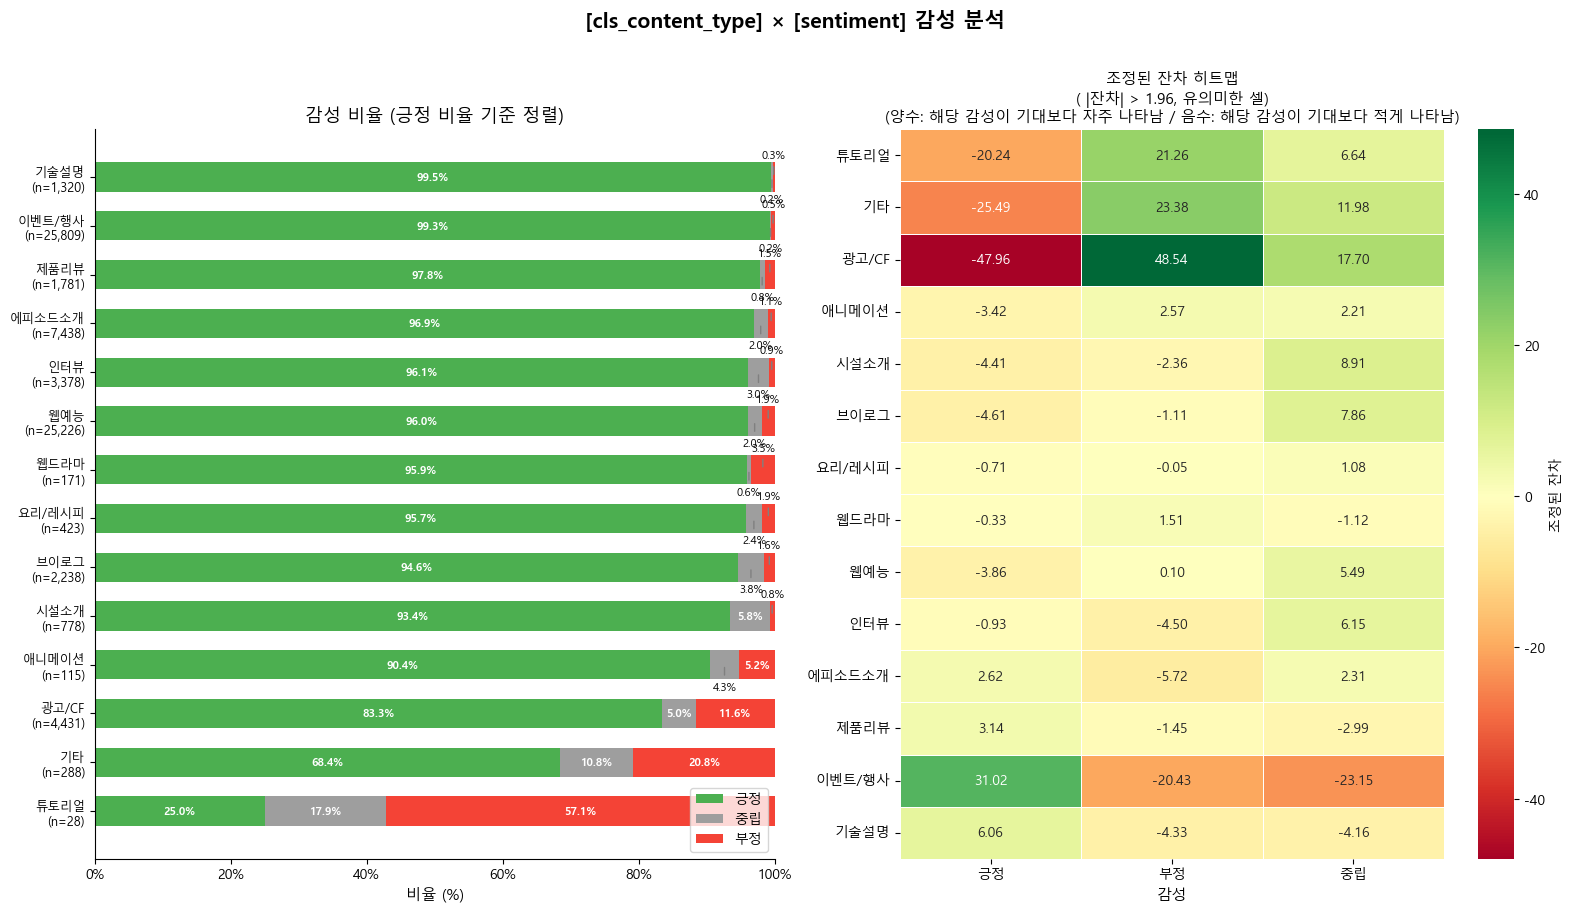

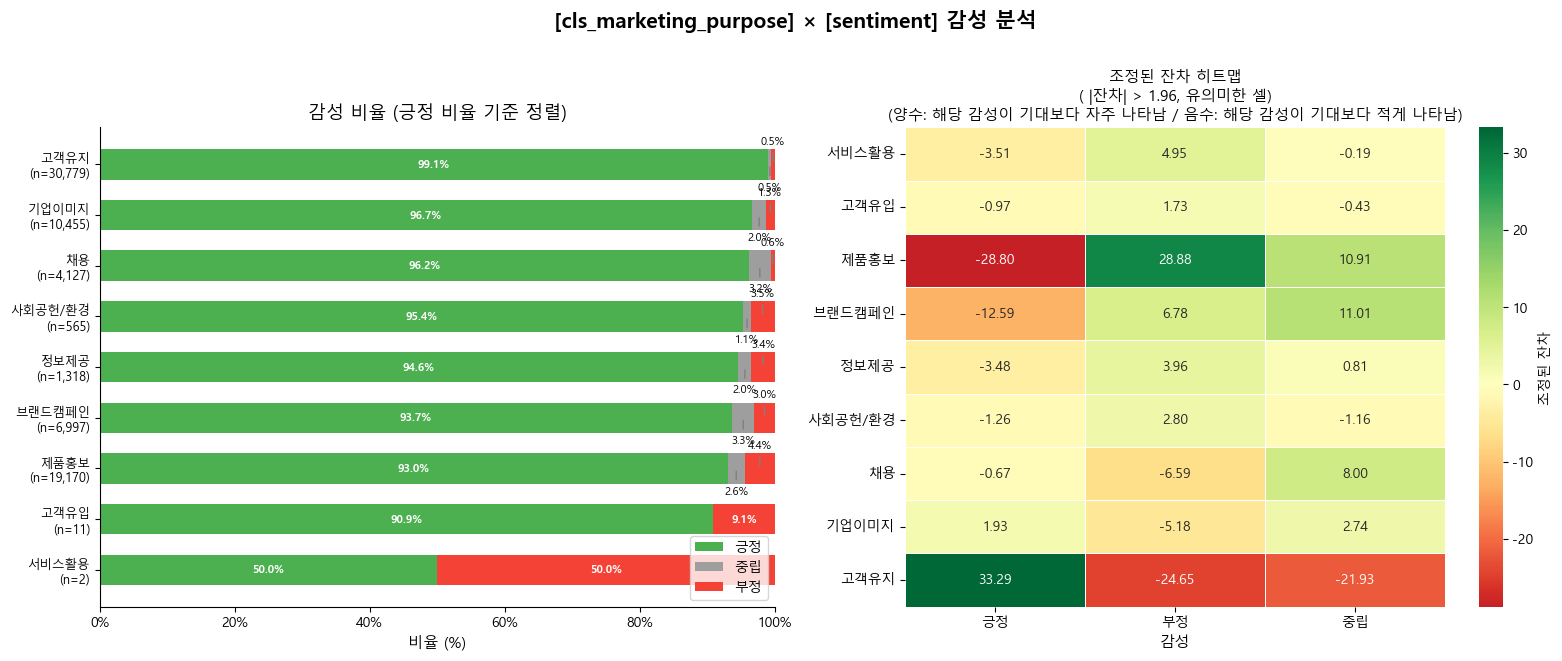

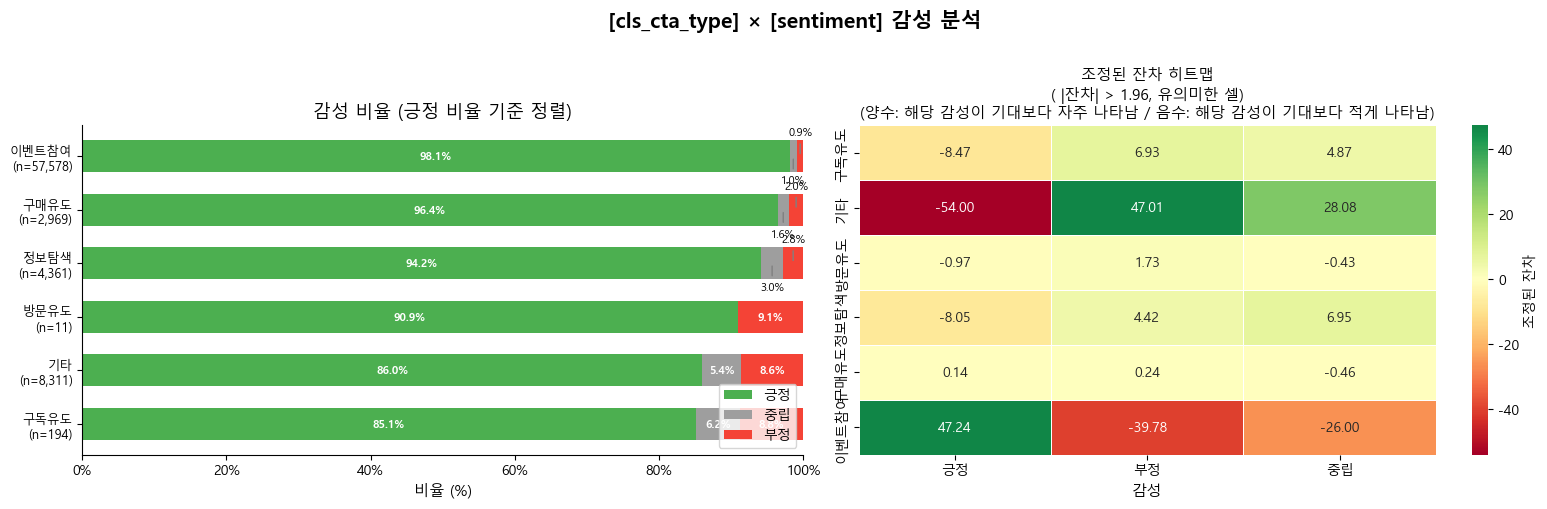

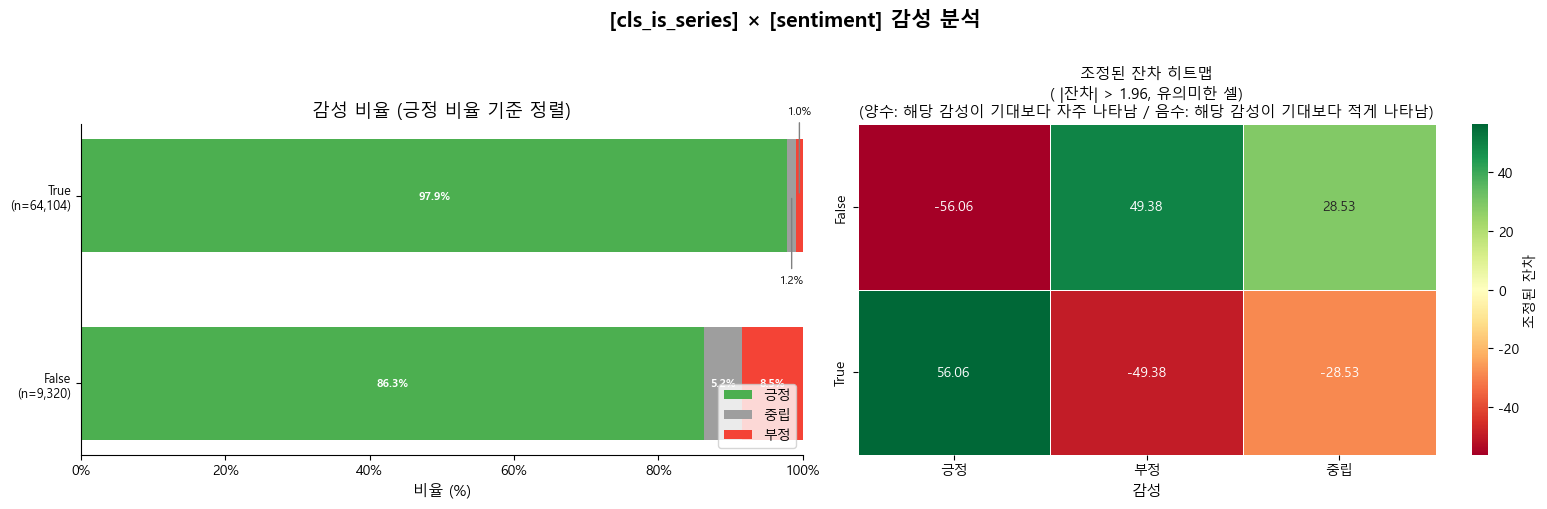

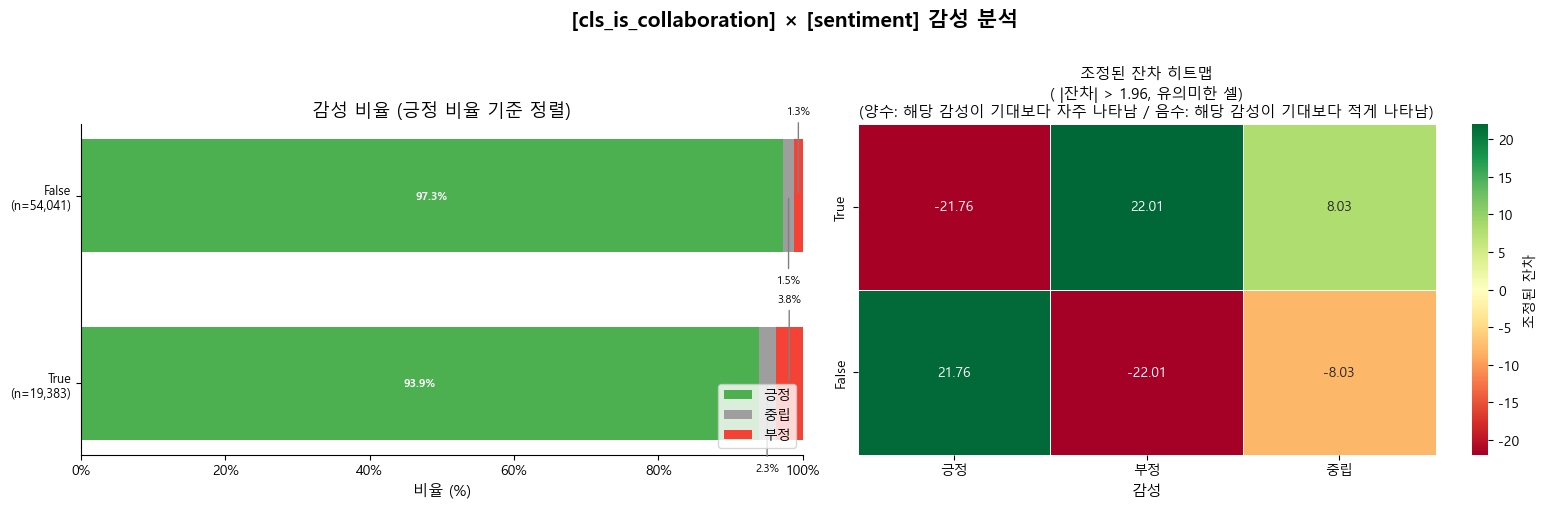

In [17]:
# ========================================
# 성공으로 분류된 영상 데이터의 검정 결과 시각화
# ========================================

# [역할] 카이제곱 검정 결과를 시각화
# [작업] 각 컬럼에 대해 visualize_chi2 함수 실행

for col in CATEGORICAL_COLS:
    visualize_chi2(df_success, col, results_success[col])
    plt.show()

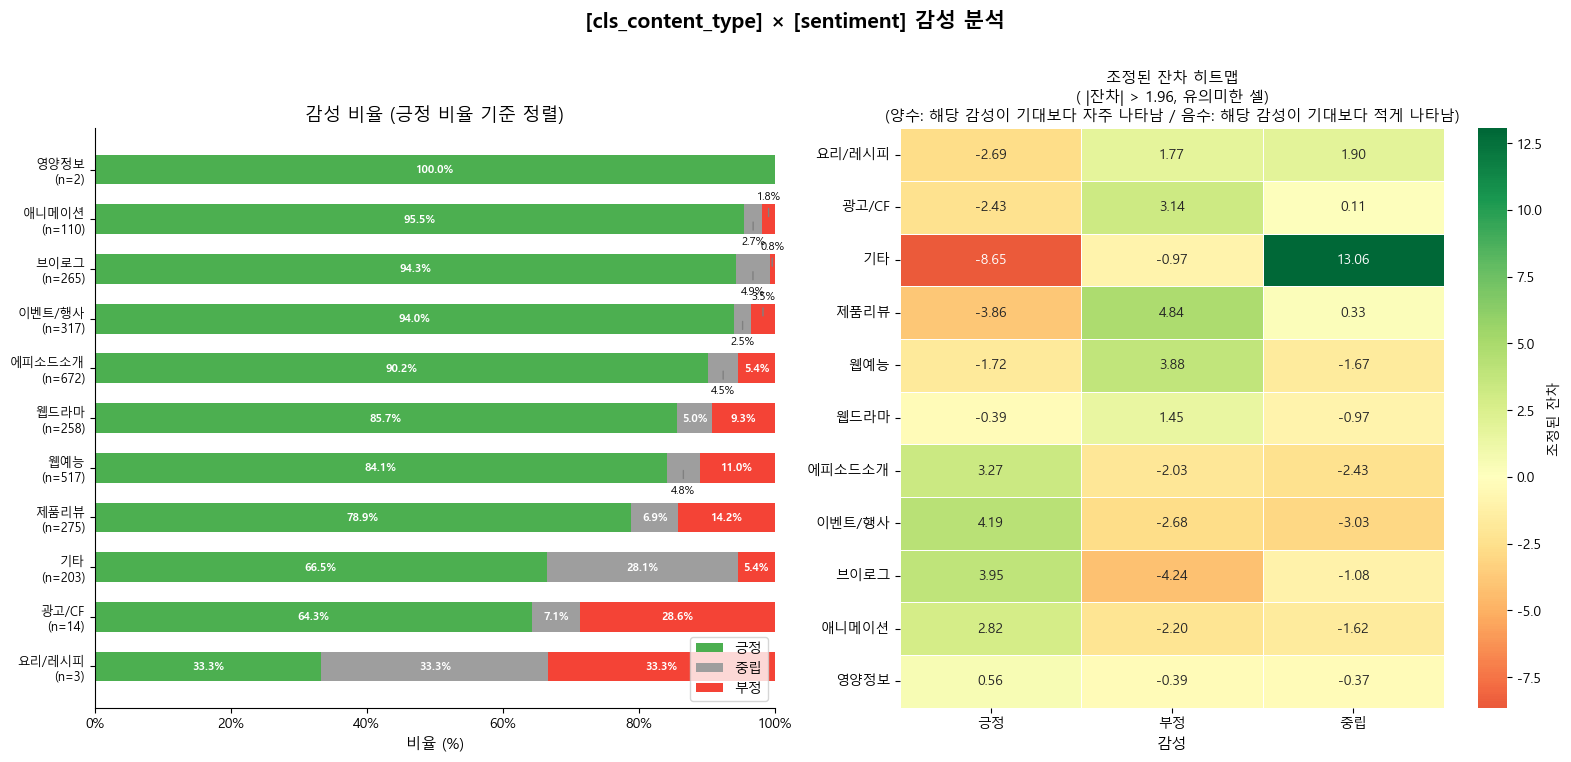

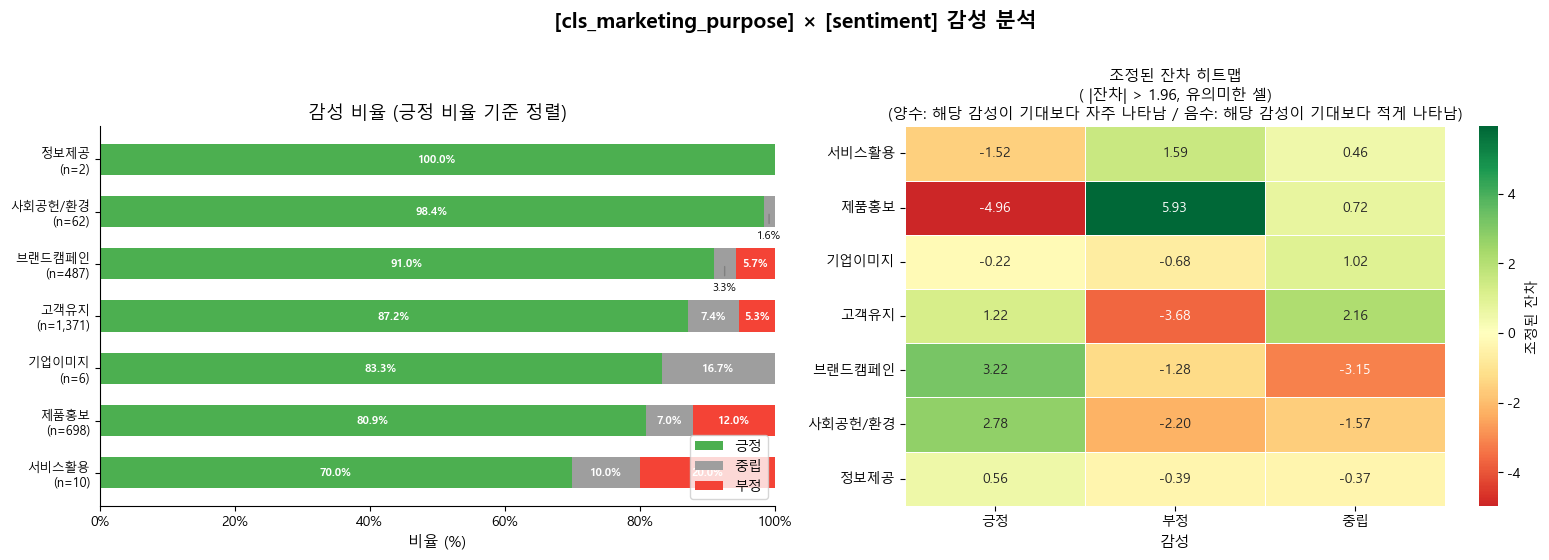

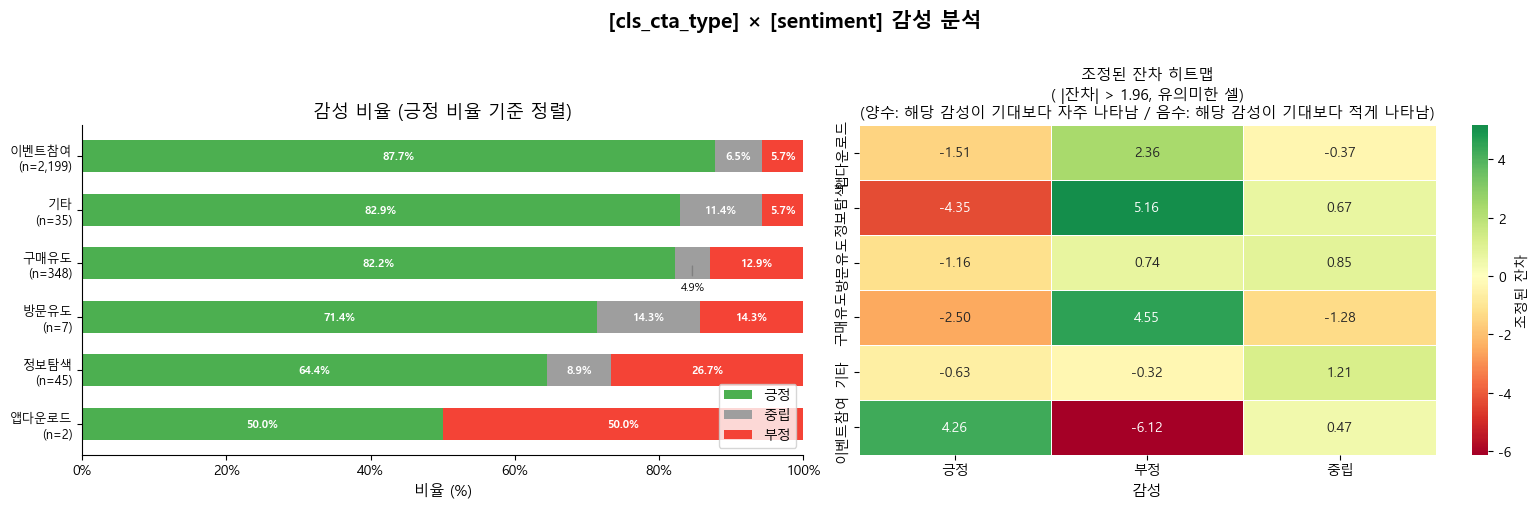

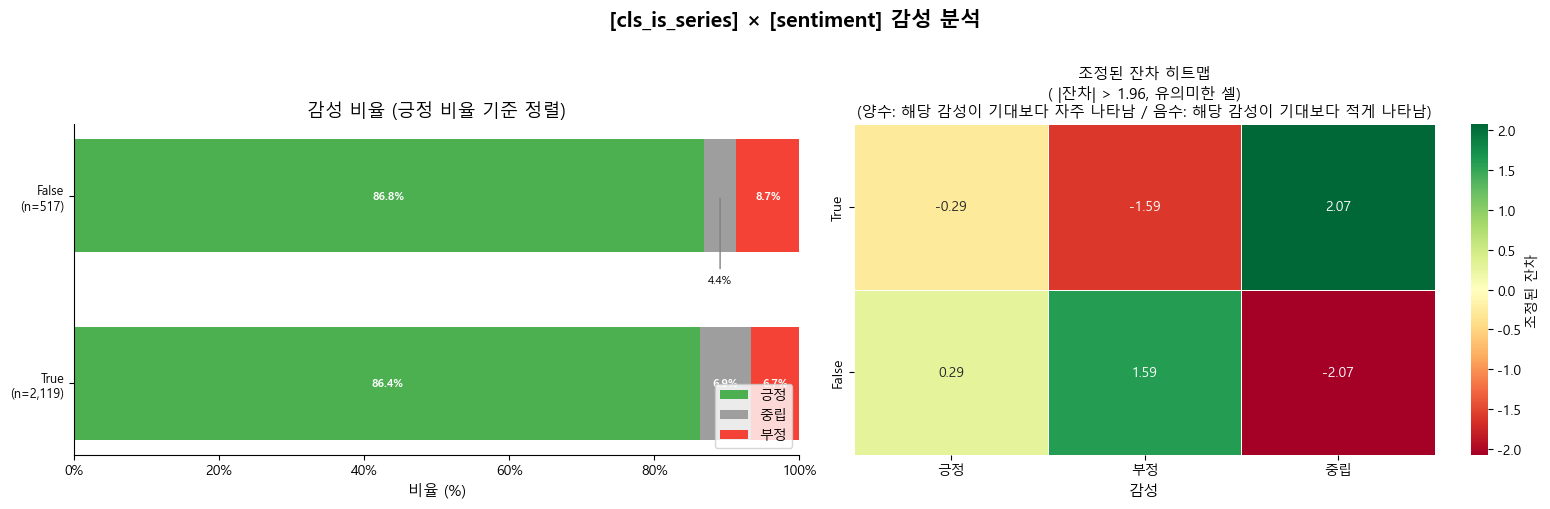

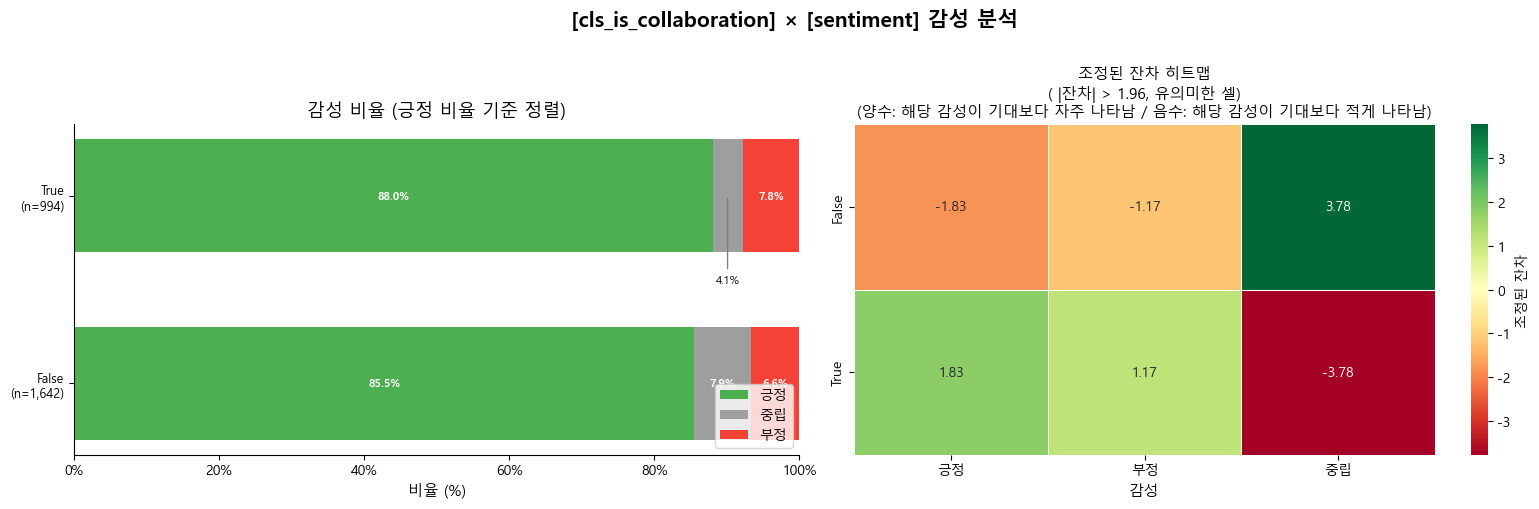

In [18]:
# ========================================
# 실패로 분류된 영상 데이터의 검정 결과 시각화
# ========================================

# [역할] 카이제곱 검정 결과를 시각화
# [작업] 각 컬럼에 대해 visualize_chi2 함수 실행

for col in CATEGORICAL_COLS:
    visualize_chi2(df_fail, col, results_fail[col])
    plt.show()

---
### **두 가지 정보의 조합에서 댓글의 감성 분석하기 (1)**
- `content_type × is_series` 분석
    - is_series=True  → content_type별 긍정 비율 계산
    - is_series=False → content_type별 긍정 비율 계산
    - 각 content_type마다 시리즈일때의 긍정률 vs 시리즈가 아닐 때의 긍정률 비교
    - 시리즈가 유리한 콘텐츠 유형 / 시리즈로 제작하지 않는 것(단독)이 유리한 콘텐츠 유형 도출이 목표

In [19]:
# ========================================
# [분석] content_type × is_series 교차 분석
# ========================================

# [역할] 성공/실패 영상 각각에서, 시리즈 여부에 따라
#        콘텐츠 유형별 댓글 긍정 비율이 달라지는지 분석
# [근거] 성공/실패를 분리하여 분석함으로써
#        "어떤 콘텐츠 유형을 시리즈로 만들면 긍정 반응을 얻는지"를
#        성과 그룹별로 독립적으로 도출할 수 있음

def analyze_content_type_x_is_series(df_input, group_label):
    """
    특정 성과 그룹(성공 또는 실패) 내에서
    content_type × is_series 교차 분석을 수행하는 함수

    Parameters
    ----------
    df_input : 분석 대상 데이터프레임 (df_success 또는 df_fail)
    group_label: 출력 및 파일명에 사용할 레이블 (예: '성공', '실패')
    """

    print(f"\n{'='*60}")
    print(f"[{group_label} 영상] content_type × is_series 분석")
    print(f"{'='*60}")

    # ── 0. 분석용 컬럼 추출 ─────────────────────────────────────
    # [작업] 분석에 필요한 컬럼만 추출
    df_cross = df_input[['video_id', 'cls_content_type', 'cls_is_series', 'sentiment']].copy()

    print(f"\n[cls_is_series 분포]")
    print(df_cross['cls_is_series'].value_counts())
    print(f"\n[cls_content_type 분포]")
    print(df_cross['cls_content_type'].value_counts())

    # ── 1. 긍정 여부 컬럼 생성 ──────────────────────────────────
    # [작업] sentiment == '긍정'이면 1, 아니면 0
    df_cross['is_positive'] = (df_cross['sentiment'] == '긍정').astype(int)

    # ── 2. (cls_content_type × cls_is_series)별 긍정 비율 집계 ──
    agg = (
        df_cross.groupby(['cls_content_type', 'cls_is_series'])['is_positive']
        .agg(positive_count='sum', total='count')
        .reset_index()
    )
    agg['positive_ratio'] = agg['positive_count'] / agg['total']

    print(f"\n=== (콘텐츠 유형 × 시리즈 여부)별 긍정 비율 ===")
    display(agg.sort_values(['cls_content_type', 'cls_is_series']).reset_index(drop=True))

    # ── 3. 피벗: 시리즈 vs 단독 나란히 비교 ──────────────────────
    # [작업] cls_is_series를 컬럼으로 피벗
    # [주의] 한쪽 조건(시리즈/단독)이 없는 content_type은 NaN으로 남음
    pivot = agg.pivot_table(
        index='cls_content_type',
        columns='cls_is_series',  # 컬럼명이 cls_is_series의 고유값인 True/False로 생성됨
        values='positive_ratio'
    ).reset_index()
    
    pivot.columns.name = None

    pivot = pivot.rename(columns={
        True: '시리즈_긍정률',
        False: '단독_긍정률'
    })

    # [작업] 차이 계산 후 유리한 형식 판별
    # 차이(시리즈-단독) > 0 : 시리즈_긍정률 > 단독_긍정률 → 시리즈가 유리한 콘텐츠 유형
    # 차이(시리즈-단독) < 0 : 단독_긍정률 > 시리즈_긍정률 → 단독이 유리한 콘텐츠 유형
    # [참고] 최종 결론 테이블은 차이 기준 내림차순 정렬이므로
    #        표 위쪽(양수) = 시리즈 유리, 표 아래쪽(음수) = 단독 유리
    pivot['차이(시리즈-단독)'] = pivot['시리즈_긍정률'] - pivot['단독_긍정률']
    pivot['해석'] = pivot['차이(시리즈-단독)'].apply(
        lambda x: '🟢 시리즈물일 때, 유리함' if x > 0 else ('🔵 시리즈물이 아닐 때, 유리함' if x < 0 else '➖ 동일')
    )

    # ── 4. 통계 검정 (카이제곱 or Fisher's exact) ─────────────────
    # [작업] 각 content_type 내에서 is_series와 sentiment(긍정/비긍정) 간
    #        연관성이 통계적으로 유의한지 검정
    stat_results = []

    for ctype in df_cross['cls_content_type'].unique():
        sub = df_cross[df_cross['cls_content_type'] == ctype]
        ct = pd.crosstab(sub['is_positive'], sub['cls_is_series'])

        n_series = int(sub['cls_is_series'].sum())
        n_non_series = int((~sub['cls_is_series']).sum())

        # 한쪽 조건이 없으면 검정 불가
        if ct.shape != (2, 2):
            stat_results.append({
                'content_type':  ctype,
                'n_series': n_series, # 시리즈물인 영상의 개수
                'n_non_series':  n_non_series, # 시리즈물이 아닌 영상의 개수
                'p_value': float('nan'),
                'effect_size(φ)': float('nan'),
                'test':'skip(한쪽조건없음)',
                'significant':   False
            })
            continue
        
        # 시리즈/단독 각각 최소 30개 미만이면 검정 불가
        # 이유: 샘플이 너무 작으면 p값이 유의해도 신뢰하기 어려움
        if n_series < 30 or n_non_series < 30:
            stat_results.append({
                'content_type':  ctype,
                'n_series': n_series,
                'n_non_series':  n_non_series,
                'p_value': float('nan'),
                'effect_size(φ)': float('nan'),
                'test':'skip(샘플부족)',
                'significant':   False
            })
            continue

        # 카이제곱으로 기대빈도를 먼저 계산하여 검정 방법을 결정
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            chi2, p, dof, expected = chi2_contingency(ct)

        if (expected < 5).any():
            # 기대빈도 < 5인 셀이 있으면 Fisher's exact로 교체
            # 이유: 샘플이 작을 때 카이제곱 근사값이 부정확해지므로
            #       정확한 확률을 직접 계산하는 Fisher's exact를 사용
            _, p = fisher_exact(ct)
            test_name = "Fisher's exact"
        else:
            test_name = "Chi-square"

        # 효과크기: 파이 계수(φ) 계산
        # φ = sqrt(χ² / n) → 2×2 표에서 두 범주형 변수 간 연관성의 강도
        # 한 가지 콘텐츠 유형마다 통계 검정을 수행하고 있기 때문에 2×2 표가 맞음
        # 해석 기준(Cohen's w): 0.1 미만(매우 작은 효과), 0.1~0.3(작은 효과), 0.3~0.5(중간 효과), 0.5 이상(큰 효과)
        n_total = sub['cls_is_series'].count()
        phi = round(np.sqrt(chi2 / n_total), 4)

        stat_results.append({
            'content_type': ctype,
            'n_series': n_series, # 시리즈물인 영상의 개수
            'n_non_series': n_non_series, # 시리즈물이 아닌 영상의 개수
            'p_value': round(p, 4),
            'effect_size(φ)': phi,
            'test': test_name,
            'significant': p < 0.05 # 통계적 유의성 
        })

    stat_df = pd.DataFrame(stat_results).sort_values('p_value')
    print(f"\n=== 통계 검정 결과 ===")
    display(stat_df.reset_index(drop=True))

    # ── 5. 최종 결론 테이블 ──────────────────────────────────────
    # [작업] 긍정률 피벗 + 검정 결과 합치기
    # [근거] 통계적으로 유의하지 않은 차이는 결론으로 채택하지 않음
    df_final = pivot.merge(
        stat_df[['content_type', 'p_value', 'effect_size(φ)', 'significant', 'test']],
        left_on='cls_content_type',
        right_on='content_type',
        how='left'
    ).drop(columns='content_type')

    df_final['결론'] = df_final.apply(
        lambda row: row['해석'] if row['significant'] else '⚠️ 통계적으로 유의하지 않음',
        axis=1
    )

    print(f"\n=== [{group_label}] 최종 분석 결론 ===")
    display(
        df_final[[
            'cls_content_type', '시리즈_긍정률', '단독_긍정률',
            '차이(시리즈-단독)', 'p_value', 'effect_size(φ)', '결론'
        ]]
        .sort_values('차이(시리즈-단독)', ascending=False)
        .reset_index(drop=True)
    )

    # ── 6. 시각화 ────────────────────────────────────────────────
    # 샘플 부족 또는 한쪽 조건 없음으로 skip된 항목은 그래프에서도 제외
    valid_types = stat_df[stat_df['significant'] | (stat_df['p_value'].notna())]['content_type'].tolist()
    plot_df = (
        df_final[df_final['cls_content_type'].isin(valid_types)]
        .set_index('cls_content_type')[['시리즈_긍정률', '단독_긍정률']]
        .dropna()
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(plot_df))
    width = 0.35

    ax.bar(x - width/2, plot_df['시리즈_긍정률'], width, label='시리즈', color='#4C72B0', alpha=0.85)
    ax.bar(x + width/2, plot_df['단독_긍정률'],   width, label='단독',   color='#DD8452', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=25, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('긍정 댓글 비율')
    ax.set_title(f'[{group_label} 영상] 콘텐츠 유형별 시리즈 vs 단독 긍정 댓글 비율', fontsize=12)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return df_final


[성공 영상] content_type × is_series 분석

[cls_is_series 분포]
cls_is_series
True     64104
False     9320
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
이벤트/행사    25809
웹예능       25226
에피소드소개     7438
광고/CF      4431
인터뷰        3378
브이로그       2238
제품리뷰       1781
기술설명       1320
시설소개        778
요리/레시피      423
기타          288
웹드라마        171
애니메이션       115
튜토리얼         28
Name: count, dtype: int64

=== (콘텐츠 유형 × 시리즈 여부)별 긍정 비율 ===


,cls_content_type,cls_is_series,positive_count,total,positive_ratio
0,광고/CF,False,3693,4431,0.833446
1,기술설명,False,2,2,1.000000
2,기술설명,True,1311,1318,0.994689
3,기타,False,124,202,0.613861
4,기타,True,73,86,0.848837
5,브이로그,False,1286,1332,0.965465
6,브이로그,True,831,906,0.917219
7,시설소개,True,727,778,0.934447
8,애니메이션,True,104,115,0.904348
9,에피소드소개,False,173,219,0.789954



=== 통계 검정 결과 ===


,content_type,n_series,n_non_series,p_value,effect_size(φ),test,significant
0,웹예능,22838,2388,0.0000,0.1304,Chi-square,True
1,브이로그,906,1332,0.0000,0.1027,Chi-square,True
2,이벤트/행사,25104,705,0.0000,0.1596,Chi-square,True
3,에피소드소개,7219,219,0.0000,0.1784,Chi-square,True
4,기타,86,202,0.0002,0.2232,Chi-square,True
5,제품리뷰,1770,11,NaN,NaN,skip(샘플부족),False
6,인터뷰,3376,2,NaN,NaN,skip(샘플부족),False
7,요리/레시피,423,0,NaN,NaN,skip(한쪽조건없음),False
8,애니메이션,115,0,NaN,NaN,skip(한쪽조건없음),False
9,광고/CF,0,4431,NaN,NaN,skip(한쪽조건없음),False



=== [성공] 최종 분석 결론 ===


,cls_content_type,시리즈_긍정률,단독_긍정률,차이(시리즈-단독),p_value,effect_size(φ),결론
0,인터뷰,0.961493,0.000000,0.961493,NaN,NaN,⚠️ 통계적으로 유의하지 않음
1,제품리뷰,0.979661,0.636364,0.343297,NaN,NaN,⚠️ 통계적으로 유의하지 않음
2,기타,0.848837,0.613861,0.234976,0.0002,0.2232,"🟢 시리즈물일 때, 유리함"
3,에피소드소개,0.974650,0.789954,0.184696,0.0000,0.1784,"🟢 시리즈물일 때, 유리함"
4,웹예능,0.968430,0.881072,0.087358,0.0000,0.1304,"🟢 시리즈물일 때, 유리함"
5,이벤트/행사,0.995140,0.912057,0.083083,0.0000,0.1596,"🟢 시리즈물일 때, 유리함"
6,기술설명,0.994689,1.000000,-0.005311,NaN,NaN,⚠️ 통계적으로 유의하지 않음
7,브이로그,0.917219,0.965465,-0.048247,0.0000,0.1027,"🔵 시리즈물이 아닐 때, 유리함"
8,광고/CF,NaN,0.833446,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음
9,시설소개,0.934447,NaN,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음


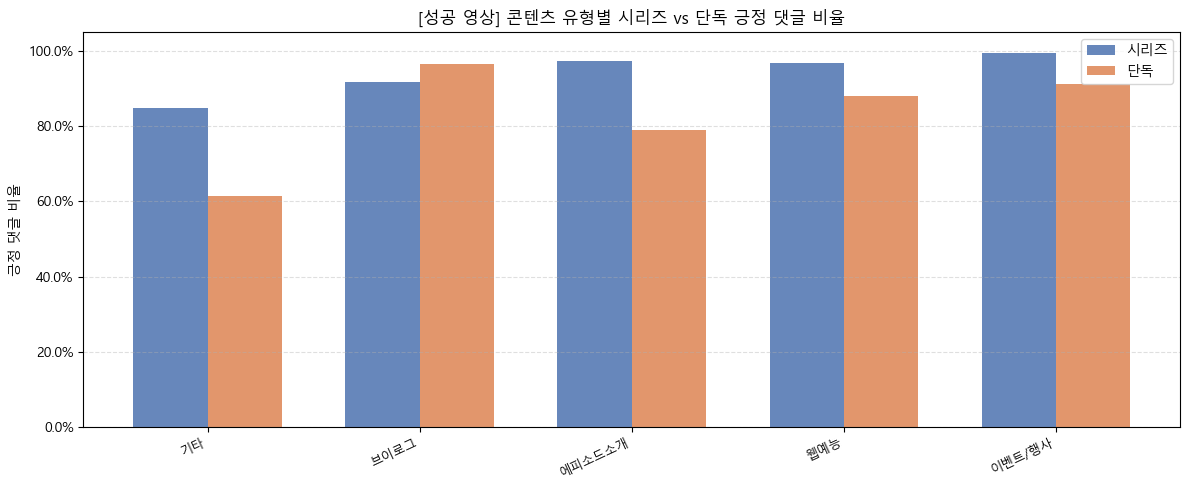

In [20]:
# 성공 영상에서 시리즈가 유리한 콘텐츠 유형, 시리즈가 아닐 때 유리한 콘텐츠 유형 확인용
df_final_success_series = analyze_content_type_x_is_series(df_success, '성공')


[실패 영상] content_type × is_series 분석

[cls_is_series 분포]
cls_is_series
True     2119
False     517
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
에피소드소개    672
웹예능       517
이벤트/행사    317
제품리뷰      275
브이로그      265
웹드라마      258
기타        203
애니메이션     110
광고/CF      14
요리/레시피      3
영양정보        2
Name: count, dtype: int64

=== (콘텐츠 유형 × 시리즈 여부)별 긍정 비율 ===


,cls_content_type,cls_is_series,positive_count,total,positive_ratio
0,광고/CF,False,9,14,0.642857
1,기타,False,15,26,0.576923
2,기타,True,120,177,0.677966
3,브이로그,False,124,125,0.992000
4,브이로그,True,126,140,0.900000
5,애니메이션,True,105,110,0.954545
6,에피소드소개,True,606,672,0.901786
7,영양정보,True,2,2,1.000000
8,요리/레시피,False,0,2,0.000000
9,요리/레시피,True,1,1,1.000000



=== 통계 검정 결과 ===


,content_type,n_series,n_non_series,p_value,effect_size(φ),test,significant
0,브이로그,140,125,0.0030,0.1824,Chi-square,True
1,웹드라마,213,45,0.0182,0.1471,Chi-square,True
2,이벤트/행사,254,63,0.1381,0.0758,Fisher's exact,False
3,웹예능,301,216,0.2453,0.0511,Chi-square,False
4,기타,177,26,NaN,NaN,skip(샘플부족),False
5,제품리뷰,249,26,NaN,NaN,skip(샘플부족),False
6,애니메이션,110,0,NaN,NaN,skip(한쪽조건없음),False
7,에피소드소개,672,0,NaN,NaN,skip(한쪽조건없음),False
8,광고/CF,0,14,NaN,NaN,skip(한쪽조건없음),False
9,요리/레시피,1,2,NaN,NaN,skip(샘플부족),False



=== [실패] 최종 분석 결론 ===


,cls_content_type,시리즈_긍정률,단독_긍정률,차이(시리즈-단독),p_value,effect_size(φ),결론
0,요리/레시피,1.000000,0.000000,1.000000,NaN,NaN,⚠️ 통계적으로 유의하지 않음
1,웹드라마,0.882629,0.733333,0.149296,0.0182,0.1471,"🟢 시리즈물일 때, 유리함"
2,기타,0.677966,0.576923,0.101043,NaN,NaN,⚠️ 통계적으로 유의하지 않음
3,제품리뷰,0.795181,0.730769,0.064411,NaN,NaN,⚠️ 통계적으로 유의하지 않음
4,웹예능,0.823920,0.865741,-0.041820,0.2453,0.0511,⚠️ 통계적으로 유의하지 않음
5,이벤트/행사,0.929134,0.984127,-0.054993,0.1381,0.0758,⚠️ 통계적으로 유의하지 않음
6,브이로그,0.900000,0.992000,-0.092000,0.0030,0.1824,"🔵 시리즈물이 아닐 때, 유리함"
7,광고/CF,NaN,0.642857,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음
8,애니메이션,0.954545,NaN,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음
9,에피소드소개,0.901786,NaN,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음


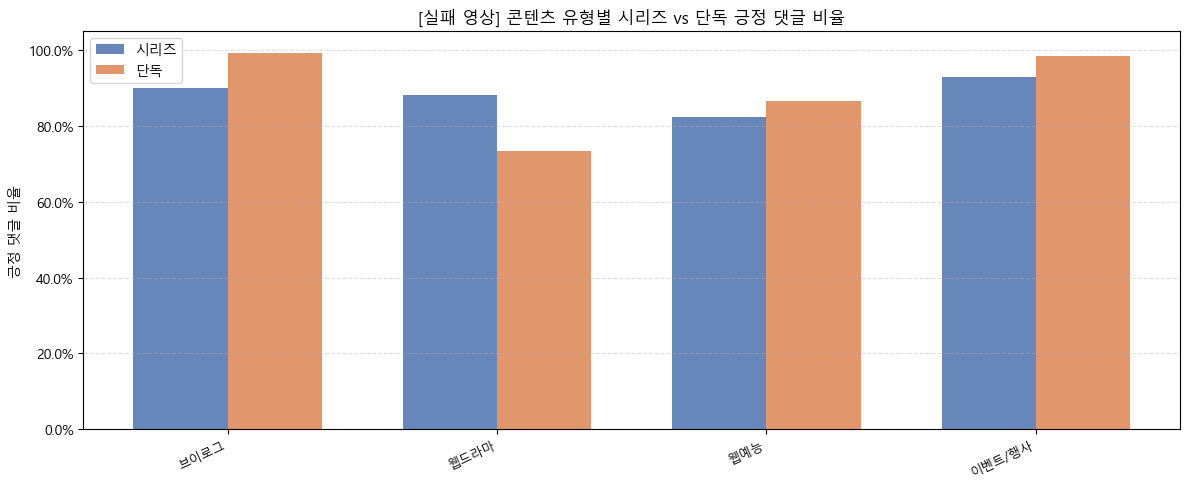

In [21]:
# 실패 영상에서 시리즈가 유리한 콘텐츠 유형, 시리즈가 아닐 때 유리한 콘텐츠 유형 확인용
df_final_fail_series = analyze_content_type_x_is_series(df_fail,'실패')

---
### **두 가지 정보의 조합에서 댓글의 감성 분석하기 (2)**
- `content_type × is_collaboration` 분석
    - is_collaboration=True → content_type별 긍정 비율 계산
    - is_collaboration=False → content_type별 긍정 비율 계산
    - 어떤 콘텐츠 유형에서 콜라보한 영상이 긍정적인 반응을 이끌어내기에 유리한지, 
    또 어떤 콘텐츠 유형에서 콜라보하지 않은 영상이 유리한지 확인하는 것이 목표임 

In [22]:
# ========================================
# [분석] content_type × is_collaboration 교차 분석
# ========================================

# [역할] 성공/실패 영상 각각에서, 콜라보 여부에 따라
#        콘텐츠 유형별 댓글 긍정 비율이 달라지는지 분석
# [근거] 성공/실패를 분리하여 분석함으로써
#        "어떤 콘텐츠 유형을 콜라보로 만들면 긍정 반응을 얻는지"를
#        성과 그룹별로 독립적으로 도출할 수 있음

def analyze_content_type_x_is_collaboration(df_input, group_label):
    """
    특정 성과 그룹(성공 또는 실패) 내에서
    content_type × is_collaboration 교차 분석을 수행하는 함수

    Parameters
    ----------
    df_input   : 분석 대상 데이터프레임 (df_success 또는 df_fail)
    group_label: 출력 및 파일명에 사용할 레이블 (예: '성공', '실패')
    """

    print(f"\n{'='*60}")
    print(f"[{group_label} 영상] content_type × is_collaboration 분석")
    print(f"{'='*60}")

    # ── 0. 분석용 컬럼 추출 ─────────────────────────────────────
    # [작업] 분석에 필요한 컬럼만 추출
    df_cross = df_input[['video_id', 'cls_content_type', 'cls_is_collaboration', 'sentiment']].copy()

    print(f"\n[cls_is_collaboration 분포]")
    print(df_cross['cls_is_collaboration'].value_counts())
    print(f"\n[cls_content_type 분포]")
    print(df_cross['cls_content_type'].value_counts())

    # ── 1. 긍정 여부 컬럼 생성 ──────────────────────────────────
    # [작업] sentiment == '긍정'이면 1, 아니면 0
    df_cross['is_positive'] = (df_cross['sentiment'] == '긍정').astype(int)

    # ── 2. (cls_content_type × cls_is_collaboration)별 긍정 비율 집계 ──
    agg = (
        df_cross.groupby(['cls_content_type', 'cls_is_collaboration'])['is_positive']
        .agg(positive_count='sum', total='count')
        .reset_index()
    )
    agg['positive_ratio'] = agg['positive_count'] / agg['total']

    print(f"\n=== (콘텐츠 유형 × 콜라보 여부)별 긍정 비율 ===")
    display(agg.sort_values(['cls_content_type', 'cls_is_collaboration']).reset_index(drop=True))

    # ── 3. 피벗: 콜라보 vs 단독 나란히 비교 ──────────────────────
    # [작업] cls_is_collaboration을 컬럼으로 피벗
    # [주의] 한쪽 조건(콜라보/단독)이 없는 content_type은 NaN으로 남음
    pivot = agg.pivot_table(
        index='cls_content_type',
        columns='cls_is_collaboration',  # 컬럼명이 cls_is_collaboration의 고유값인 True/False로 생성됨
        values='positive_ratio'
    ).reset_index()

    pivot.columns.name = None

    pivot = pivot.rename(columns={
        True:  '콜라보_긍정률',
        False: '단독_긍정률'
    })

    # [작업] 차이 계산 후 유리한 형식 판별
    # 차이(콜라보-단독) > 0 : 콜라보_긍정률 > 단독_긍정률 → 콜라보가 유리한 콘텐츠 유형
    # 차이(콜라보-단독) < 0 : 단독_긍정률 > 콜라보_긍정률 → 단독이 유리한 콘텐츠 유형
    # [참고] 최종 결론 테이블은 차이 기준 내림차순 정렬이므로
    #        표 위쪽(양수) = 콜라보 유리, 표 아래쪽(음수) = 단독 유리
    pivot['차이(콜라보-단독)'] = pivot['콜라보_긍정률'] - pivot['단독_긍정률']
    pivot['해석'] = pivot['차이(콜라보-단독)'].apply(
        lambda x: '🟢 콜라보일 때, 유리함' if x > 0 else ('🔵 콜라보하지 않을 때, 유리함' if x < 0 else '➖ 동일')
    )

    # ── 4. 통계 검정 (카이제곱 or Fisher's exact) ─────────────────
    # [작업] 각 content_type 내에서 is_collaboration과 sentiment(긍정/비긍정) 간
    #        연관성이 통계적으로 유의한지 검정
    stat_results = []

    for ctype in df_cross['cls_content_type'].unique():
        sub = df_cross[df_cross['cls_content_type'] == ctype]
        ct = pd.crosstab(sub['is_positive'], sub['cls_is_collaboration'])

        n_collaboration     = int(sub['cls_is_collaboration'].sum())
        n_non_collaboration = int((~sub['cls_is_collaboration']).sum())

        # 한쪽 조건이 없으면 검정 불가
        if ct.shape != (2, 2):
            stat_results.append({
                'content_type':       ctype,
                'n_collaboration':     n_collaboration,     # 콜라보 영상의 댓글 수
                'n_non_collaboration': n_non_collaboration, # 단독 영상의 댓글 수
                'p_value':            float('nan'),
                'effect_size(φ)':     float('nan'),
                'test':               'skip(한쪽조건없음)',
                'significant':        False
            })
            continue

        # 콜라보/단독 각각 최소 30개 미만이면 검정 불가
        # 이유: 샘플이 너무 작으면 p값이 유의해도 신뢰하기 어려움
        if n_collaboration < 30 or n_non_collaboration < 30:
            stat_results.append({
                'content_type':       ctype,
                'n_collaboration':     n_collaboration,
                'n_non_collaboration': n_non_collaboration,
                'p_value':            float('nan'),
                'effect_size(φ)':     float('nan'),
                'test':               'skip(샘플부족)',
                'significant':        False
            })
            continue

        # 카이제곱으로 기대빈도를 먼저 계산하여 검정 방법을 결정
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            chi2, p, dof, expected = chi2_contingency(ct)

        if (expected < 5).any():
            # 기대빈도 < 5인 셀이 있으면 Fisher's exact로 교체
            # 이유: 샘플이 작을 때 카이제곱 근사값이 부정확해지므로
            #       정확한 확률을 직접 계산하는 Fisher's exact를 사용
            _, p = fisher_exact(ct)
            test_name = "Fisher's exact"
        else:
            test_name = "Chi-square"

        # 효과크기: 파이 계수(φ) 계산
        # φ = sqrt(χ² / n) → 2×2 표에서 두 범주형 변수 간 연관성의 강도
        # 한 가지 콘텐츠 유형마다 통계 검정을 수행하고 있기 때문에 2×2 표가 맞음
        # 해석 기준(Cohen's w): 0.1 미만(매우 작은 효과), 0.1~0.3(작은 효과), 0.3~0.5(중간 효과), 0.5 이상(큰 효과)
        n_total = sub['cls_is_collaboration'].count()
        phi = round(np.sqrt(chi2 / n_total), 4)

        stat_results.append({
            'content_type':       ctype,
            'n_collaboration':     n_collaboration,     # 콜라보 영상의 댓글 수
            'n_non_collaboration': n_non_collaboration, # 단독 영상의 댓글 수
            'p_value':            round(p, 4),
            'effect_size(φ)':     phi,
            'test':               test_name,
            'significant':        p < 0.05             # 통계적 유의성
        })

    stat_df = pd.DataFrame(stat_results).sort_values('p_value')
    print(f"\n=== 통계 검정 결과 ===")
    display(stat_df.reset_index(drop=True))

    # ── 5. 최종 결론 테이블 ──────────────────────────────────────
    # [작업] 긍정률 피벗 + 검정 결과 합치기
    # [근거] 통계적으로 유의하지 않은 차이는 결론으로 채택하지 않음
    df_final = pivot.merge(
        stat_df[['content_type', 'p_value', 'effect_size(φ)', 'significant', 'test']],
        left_on='cls_content_type',
        right_on='content_type',
        how='left'
    ).drop(columns='content_type')

    df_final['결론'] = df_final.apply(
        lambda row: row['해석'] if row['significant'] else '⚠️ 통계적으로 유의하지 않음',
        axis=1
    )

    print(f"\n=== [{group_label}] 최종 분석 결론 ===")
    display(
        df_final[[
            'cls_content_type', '콜라보_긍정률', '단독_긍정률',
            '차이(콜라보-단독)', 'p_value', 'effect_size(φ)', '결론'
        ]]
        .sort_values('차이(콜라보-단독)', ascending=False)
        .reset_index(drop=True)
    )

    # ── 6. 시각화 ────────────────────────────────────────────────
    # 샘플 부족 또는 한쪽 조건 없음으로 skip된 항목은 그래프에서도 제외
    valid_types = stat_df[stat_df['significant'] | (stat_df['p_value'].notna())]['content_type'].tolist()
    plot_df = (
        df_final[df_final['cls_content_type'].isin(valid_types)]
        .set_index('cls_content_type')[['콜라보_긍정률', '단독_긍정률']]
        .dropna()
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(plot_df))
    width = 0.35

    ax.bar(x - width/2, plot_df['콜라보_긍정률'], width, label='콜라보', color='#4C72B0', alpha=0.85)
    ax.bar(x + width/2, plot_df['단독_긍정률'],   width, label='단독',   color='#DD8452', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=25, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('긍정 댓글 비율')
    ax.set_title(f'[{group_label} 영상] 콘텐츠 유형별 콜라보 vs 단독 긍정 댓글 비율', fontsize=12)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return df_final


[성공 영상] content_type × is_collaboration 분석

[cls_is_collaboration 분포]
cls_is_collaboration
False    54041
True     19383
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
이벤트/행사    25809
웹예능       25226
에피소드소개     7438
광고/CF      4431
인터뷰        3378
브이로그       2238
제품리뷰       1781
기술설명       1320
시설소개        778
요리/레시피      423
기타          288
웹드라마        171
애니메이션       115
튜토리얼         28
Name: count, dtype: int64

=== (콘텐츠 유형 × 콜라보 여부)별 긍정 비율 ===


,cls_content_type,cls_is_collaboration,positive_count,total,positive_ratio
0,광고/CF,False,2187,2576,0.848991
1,광고/CF,True,1506,1855,0.811860
2,기술설명,False,1313,1320,0.994697
3,기타,False,125,204,0.612745
4,기타,True,72,84,0.857143
5,브이로그,False,1928,2006,0.961117
6,브이로그,True,189,232,0.814655
7,시설소개,False,727,778,0.934447
8,애니메이션,False,104,115,0.904348
9,에피소드소개,False,7075,7261,0.974384



=== 통계 검정 결과 ===


,content_type,n_collaboration,n_non_collaboration,p_value,effect_size(φ),test,significant
0,인터뷰,94,3284,0.0000,0.1006,Fisher's exact,True
1,브이로그,232,2006,0.0000,0.1942,Chi-square,True
2,에피소드소개,177,7261,0.0000,0.1892,Chi-square,True
3,이벤트/행사,590,25219,0.0000,0.1272,Fisher's exact,True
4,기타,84,204,0.0001,0.2307,Chi-square,True
5,광고/CF,1855,2576,0.0012,0.0486,Chi-square,True
6,웹예능,14437,10789,0.0653,0.0116,Chi-square,False
7,요리/레시피,303,120,0.1637,0.0677,Chi-square,False
8,제품리뷰,1583,198,0.6147,0.0114,Fisher's exact,False
9,애니메이션,0,115,NaN,NaN,skip(한쪽조건없음),False



=== [성공] 최종 분석 결론 ===


,cls_content_type,콜라보_긍정률,단독_긍정률,차이(콜라보-단독),p_value,effect_size(φ),결론
0,기타,0.857143,0.612745,0.244398,0.0001,0.2307,"🟢 콜라보일 때, 유리함"
1,웹예능,0.958163,0.962833,-0.004669,0.0653,0.0116,⚠️ 통계적으로 유의하지 않음
2,제품리뷰,0.976627,0.984848,-0.008222,0.6147,0.0114,⚠️ 통계적으로 유의하지 않음
3,요리/레시피,0.947195,0.983333,-0.036139,0.1637,0.0677,⚠️ 통계적으로 유의하지 않음
4,광고/CF,0.811860,0.848991,-0.037131,0.0012,0.0486,"🔵 콜라보하지 않을 때, 유리함"
5,이벤트/행사,0.922034,0.994528,-0.072494,0.0000,0.1272,"🔵 콜라보하지 않을 때, 유리함"
6,인터뷰,0.840426,0.964373,-0.123947,0.0000,0.1006,"🔵 콜라보하지 않을 때, 유리함"
7,브이로그,0.814655,0.961117,-0.146461,0.0000,0.1942,"🔵 콜라보하지 않을 때, 유리함"
8,에피소드소개,0.757062,0.974384,-0.217322,0.0000,0.1892,"🔵 콜라보하지 않을 때, 유리함"
9,기술설명,NaN,0.994697,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음


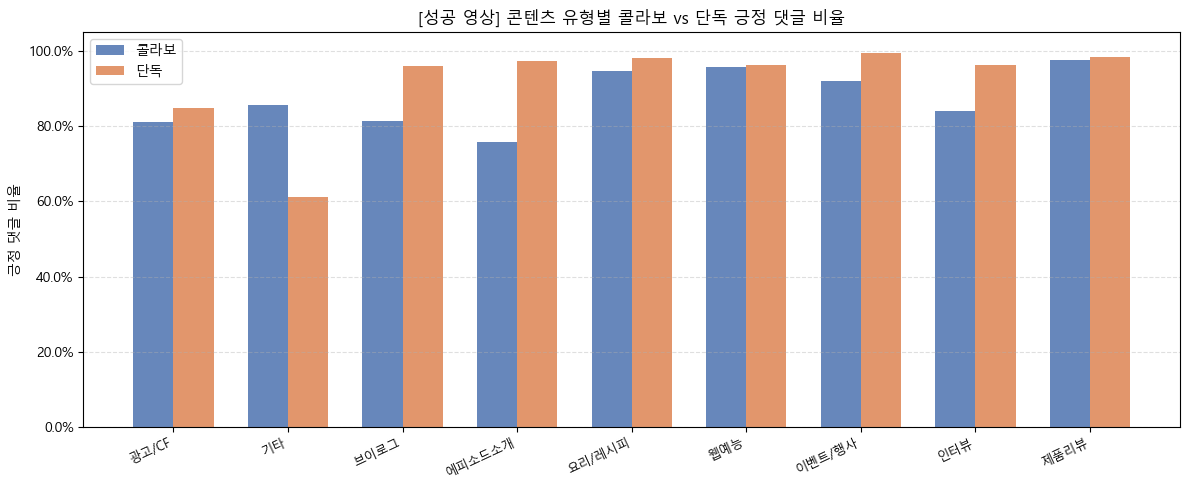

In [23]:
# 함수 실행 (성공한 영상)
final_success_collabo = analyze_content_type_x_is_collaboration(df_success, '성공')


[실패 영상] content_type × is_collaboration 분석

[cls_is_collaboration 분포]
cls_is_collaboration
False    1642
True      994
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
에피소드소개    672
웹예능       517
이벤트/행사    317
제품리뷰      275
브이로그      265
웹드라마      258
기타        203
애니메이션     110
광고/CF      14
요리/레시피      3
영양정보        2
Name: count, dtype: int64

=== (콘텐츠 유형 × 콜라보 여부)별 긍정 비율 ===


,cls_content_type,cls_is_collaboration,positive_count,total,positive_ratio
0,광고/CF,True,9,14,0.642857
1,기타,False,129,186,0.693548
2,기타,True,6,17,0.352941
3,브이로그,False,126,141,0.893617
4,브이로그,True,124,124,1.000000
5,애니메이션,False,105,110,0.954545
6,에피소드소개,False,470,501,0.938124
7,에피소드소개,True,136,171,0.795322
8,영양정보,False,2,2,1.000000
9,요리/레시피,False,1,2,0.500000



=== 통계 검정 결과 ===


,content_type,n_collaboration,n_non_collaboration,p_value,effect_size(φ),test,significant
0,에피소드소개,171,501,0.0000,0.2033,Chi-square,True
1,브이로그,124,141,0.0005,0.2133,Chi-square,True
2,웹예능,188,329,0.0021,0.1356,Chi-square,True
3,웹드라마,213,45,0.0182,0.1471,Chi-square,True
4,이벤트/행사,225,92,0.5970,0.0297,Chi-square,False
5,제품리뷰,41,234,0.7234,0.0213,Chi-square,False
6,기타,17,186,NaN,NaN,skip(샘플부족),False
7,애니메이션,0,110,NaN,NaN,skip(한쪽조건없음),False
8,광고/CF,14,0,NaN,NaN,skip(한쪽조건없음),False
9,요리/레시피,1,2,NaN,NaN,skip(샘플부족),False



=== [실패] 최종 분석 결론 ===


,cls_content_type,콜라보_긍정률,단독_긍정률,차이(콜라보-단독),p_value,effect_size(φ),결론
0,웹드라마,0.882629,0.733333,0.149296,0.0182,0.1471,"🟢 콜라보일 때, 유리함"
1,웹예능,0.909574,0.802432,0.107143,0.0021,0.1356,"🟢 콜라보일 때, 유리함"
2,브이로그,1.000000,0.893617,0.106383,0.0005,0.2133,"🟢 콜라보일 때, 유리함"
3,이벤트/행사,0.933333,0.956522,-0.023188,0.5970,0.0297,⚠️ 통계적으로 유의하지 않음
4,제품리뷰,0.756098,0.794872,-0.038774,0.7234,0.0213,⚠️ 통계적으로 유의하지 않음
5,에피소드소개,0.795322,0.938124,-0.142802,0.0000,0.2033,"🔵 콜라보하지 않을 때, 유리함"
6,기타,0.352941,0.693548,-0.340607,NaN,NaN,⚠️ 통계적으로 유의하지 않음
7,요리/레시피,0.000000,0.500000,-0.500000,NaN,NaN,⚠️ 통계적으로 유의하지 않음
8,광고/CF,0.642857,NaN,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음
9,애니메이션,NaN,0.954545,NaN,NaN,NaN,⚠️ 통계적으로 유의하지 않음


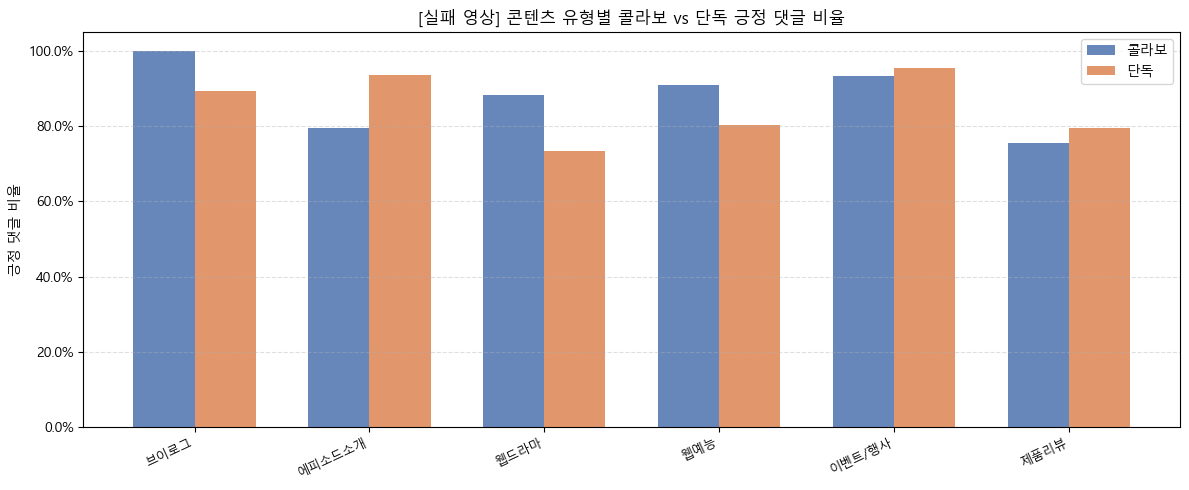

In [24]:
# 함수 실행 (실패한 영상)
final_fail_collabo = analyze_content_type_x_is_collaboration(df_fail, '실패')

---
### **두 가지 정보의 조합에서 댓글의 감성 분석하기 (3)**
- `content_type × marketing_purpose` 분석
    - 영상 업로드 목적(marketing_purpose)에 따라 어떤 유형의 영상을 제작하는 것이
    시청자의 긍정적인 반응을 이끌어내기에 유리한지 확인하는 것이 목표임

In [25]:
# ================================================
# [분석] content_type × marketing_purpose 교차 분석
# ================================================

# [역할] 성공/실패 영상 각각에서, 마케팅 목적과 콘텐츠 유형의 조합이
#        댓글 긍정 비율에 미치는 영향을 분석
# [근거] 두 범주형 변수 간 전체 연관성을 카이제곱으로 검정하고,
#        조합별 긍정률을 히트맵으로 시각화하여
#        긍정 반응을 이끌어내기에 유리한 조합을 도출

def analyze_content_type_x_marketing_purpose(df_input, group_label):
    """
    특정 성과 그룹(성공 또는 실패) 내에서
    content_type × marketing_purpose 교차 분석을 수행하는 함수

    Parameters
    ----------
    df_input   : 분석 대상 데이터프레임 (df_success 또는 df_fail)
    group_label: 출력 및 파일명에 사용할 레이블 (예: '성공', '실패')
    """

    print(f"\n{'='*60}")
    print(f"[{group_label} 영상] content_type × marketing_purpose 분석")
    print(f"{'='*60}")

    # ── 0. 분석용 컬럼 추출 ─────────────────────────────────────
    # [작업] 분석에 필요한 컬럼만 추출
    df_cross = df_input[['video_id', 'cls_content_type', 'cls_marketing_purpose', 'sentiment']].copy()

    print(f"\n[cls_marketing_purpose 분포]")
    print(df_cross['cls_marketing_purpose'].value_counts())
    print(f"\n[cls_content_type 분포]")
    print(df_cross['cls_content_type'].value_counts())

    # ── 1. 긍정 여부 컬럼 생성 ──────────────────────────────────
    # [작업] sentiment == '긍정'이면 1, 아니면 0
    df_cross['is_positive'] = (df_cross['sentiment'] == '긍정').astype(int)

    # ── 2. (cls_content_type × cls_marketing_purpose)별 긍정 비율 집계 ──
    agg = (
        df_cross.groupby(['cls_content_type', 'cls_marketing_purpose'])['is_positive']
        .agg(positive_count='sum', total='count')
        .reset_index()
    )
    agg['positive_ratio'] = agg['positive_count'] / agg['total']

    print(f"\n=== (콘텐츠 유형 × 마케팅 목적)별 긍정 비율 ===")
    display(agg.sort_values(['cls_content_type', 'cls_marketing_purpose']).reset_index(drop=True))

    # ── 3. 통계 검정: 전체 교차표 카이제곱 ───────────────────────
    # [작업] content_type × marketing_purpose 전체 교차표로 카이제곱 검정
    # [근거] marketing_purpose가 9개 범주라 개별 검정이 아닌
    #        전체 연관성을 한 번에 검정하는 방식을 사용
    # [주의] 댓글 수(total) 기준으로 교차표 생성
    #        → 각 셀: 해당 조합의 전체 댓글 수

    # 전체 교차표 생성 (행: content_type, 열: marketing_purpose, 값: 댓글 수)
    ct = pd.crosstab(df_cross['cls_content_type'], df_cross['cls_marketing_purpose'])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        chi2, p, dof, expected = chi2_contingency(ct)

    # 효과크기: Cramér's V 계산
    # [근거] 카이제곱은 표 크기에 따라 값이 달라지므로
    #        표 크기를 보정한 Cramér's V를 효과크기로 사용
    # 계산식: V = sqrt(χ² / (n × (min(행수, 열수) - 1)))
    # 해석 기준(Cohen): 0.1 미만(매우 작은 효과), 0.1~0.3(작은 효과),
    #                   0.3~0.5(중간 효과), 0.5 이상(큰 효과)
    n_total = df_cross.shape[0]
    min_dim = min(ct.shape) - 1
    cramers_v = round(np.sqrt(chi2 / (n_total * min_dim)), 4)

    print(f"\n=== 통계 검정 결과 ===")
    print(f"카이제곱 통계량 : {chi2:.4f}")
    print(f"p-value         : {p:.4f}")
    print(f"자유도          : {dof}")
    print(f"Cramér's V      : {cramers_v}")
    print(f"통계적 유의성   : {'유의함 (p < 0.05)' if p < 0.05 else '유의하지 않음 (p >= 0.05)'}")

    # ── 4. 피벗: 히트맵용 긍정률 테이블 생성 ─────────────────────
    # [작업] 행: content_type, 열: marketing_purpose, 값: positive_ratio
    # [주의] 댓글 수가 30개 미만인 셀은 NaN으로 처리하여 히트맵에서 제외
    #        → 샘플이 너무 작은 조합은 신뢰하기 어려움

    # 셀별 댓글 수 피벗 (30개 미만 필터링용)
    total_pivot = agg.pivot_table(
        index='cls_content_type',
        columns='cls_marketing_purpose',
        values='total'
    )

    # 긍정률 피벗
    ratio_pivot = agg.pivot_table(
        index='cls_content_type',
        columns='cls_marketing_purpose',
        values='positive_ratio'
    )

    # 댓글 수 30개 미만인 셀은 NaN으로 마스킹
    # [근거] 샘플이 너무 작으면 긍정률이 극단적으로 나올 수 있음
    ratio_pivot_masked = ratio_pivot.where(total_pivot >= 30)

    print(f"\n=== 조합별 긍정률 테이블 (댓글 수 30개 미만 셀은 NaN) ===")
    display(ratio_pivot_masked.round(4))

    # ── 5. 히트맵 시각화 ─────────────────────────────────────────
    # [작업] 조합별 긍정률을 히트맵으로 시각화
    # [근거] 수치 비교표보다 색상으로 패턴을 직관적으로 파악할 수 있음
    #        NaN 셀은 회색으로 표시 (데이터 부족)

    fig, ax = plt.subplots(figsize=(14, 7))

    # NaN 셀 위치 마스크 생성
    nan_mask = ratio_pivot_masked.isna()
    
    # 배경을 먼저 회색으로 깔기 (NaN 셀이 회색으로 보이도록)
    ax.set_facecolor('#D3D3D3')

    sns.heatmap(
        ratio_pivot_masked,
        annot=True,              # 셀 안에 수치 표시
        fmt='.2%',               # 퍼센트 형식
        cmap='RdYlGn',           # 빨강(낮음) → 노랑 → 초록(높음)
        vmin=0.7,                # 색상 범위 하한 (데이터에 따라 조정)
        vmax=1.0,                # 색상 범위 상한
        linewidths=0.5,
        linecolor='gray',
        mask=nan_mask,           # NaN 셀은 렌더링 제외 → 배경색(회색)이 드러남
        ax=ax,
        cbar_kws={'label': '긍정 댓글 비율'}
    )

    ax.set_title(
        f'[{group_label} 영상] 콘텐츠 유형 × 마케팅 목적별 긍정 댓글 비율\n'
        f'(Cramér\'s V={cramers_v}, p={p:.4f} / 회색=데이터 부족(30개 미만))',
        fontsize=12
    )
    ax.set_xlabel('마케팅 목적', fontsize=10)
    ax.set_ylabel('콘텐츠 유형', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    plt.tight_layout()
    plt.show()

    return ratio_pivot_masked


[성공 영상] content_type × marketing_purpose 분석

[cls_marketing_purpose 분포]
cls_marketing_purpose
고객유지       30779
제품홍보       19170
기업이미지      10455
브랜드캠페인      6997
채용          4127
정보제공        1318
사회공헌/환경      565
고객유입          11
서비스활용          2
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
이벤트/행사    25809
웹예능       25226
에피소드소개     7438
광고/CF      4431
인터뷰        3378
브이로그       2238
제품리뷰       1781
기술설명       1320
시설소개        778
요리/레시피      423
기타          288
웹드라마        171
애니메이션       115
튜토리얼         28
Name: count, dtype: int64

=== (콘텐츠 유형 × 마케팅 목적)별 긍정 비율 ===


,cls_content_type,cls_marketing_purpose,positive_count,total,positive_ratio
0,광고/CF,제품홍보,3693,4431,0.833446
1,기술설명,기업이미지,606,610,0.993443
2,기술설명,사회공헌/환경,24,25,0.960000
3,기술설명,채용,683,685,0.997080
4,기타,기업이미지,37,55,0.672727
5,기타,브랜드캠페인,90,105,0.857143
6,기타,서비스활용,1,2,0.500000
7,기타,정보제공,69,126,0.547619
8,브이로그,고객유지,191,205,0.931707
9,브이로그,기업이미지,26,31,0.838710



=== 통계 검정 결과 ===
카이제곱 통계량 : 127069.0853
p-value         : 0.0000
자유도          : 104
Cramér's V      : 0.4651
통계적 유의성   : 유의함 (p < 0.05)

=== 조합별 긍정률 테이블 (댓글 수 30개 미만 셀은 NaN) ===


cls_marketing_purpose,고객유입,고객유지,기업이미지,브랜드캠페인,사회공헌/환경,서비스활용,정보제공,제품홍보,채용
cls_content_type,,,,,,,,,
광고/CF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8334,NaN
기술설명,NaN,NaN,0.9934,NaN,NaN,NaN,NaN,NaN,0.9971
기타,NaN,NaN,0.6727,0.8571,NaN,NaN,0.5476,NaN,NaN
브이로그,NaN,0.9317,0.8387,0.8174,NaN,NaN,NaN,0.9425,0.9773
시설소개,NaN,NaN,0.8824,NaN,NaN,NaN,NaN,0.9652,NaN
애니메이션,NaN,NaN,NaN,0.9043,NaN,NaN,NaN,NaN,NaN
에피소드소개,NaN,NaN,0.9709,NaN,NaN,NaN,NaN,0.9423,0.9648
요리/레시피,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9574,NaN
웹드라마,NaN,NaN,NaN,0.9591,NaN,NaN,NaN,NaN,NaN


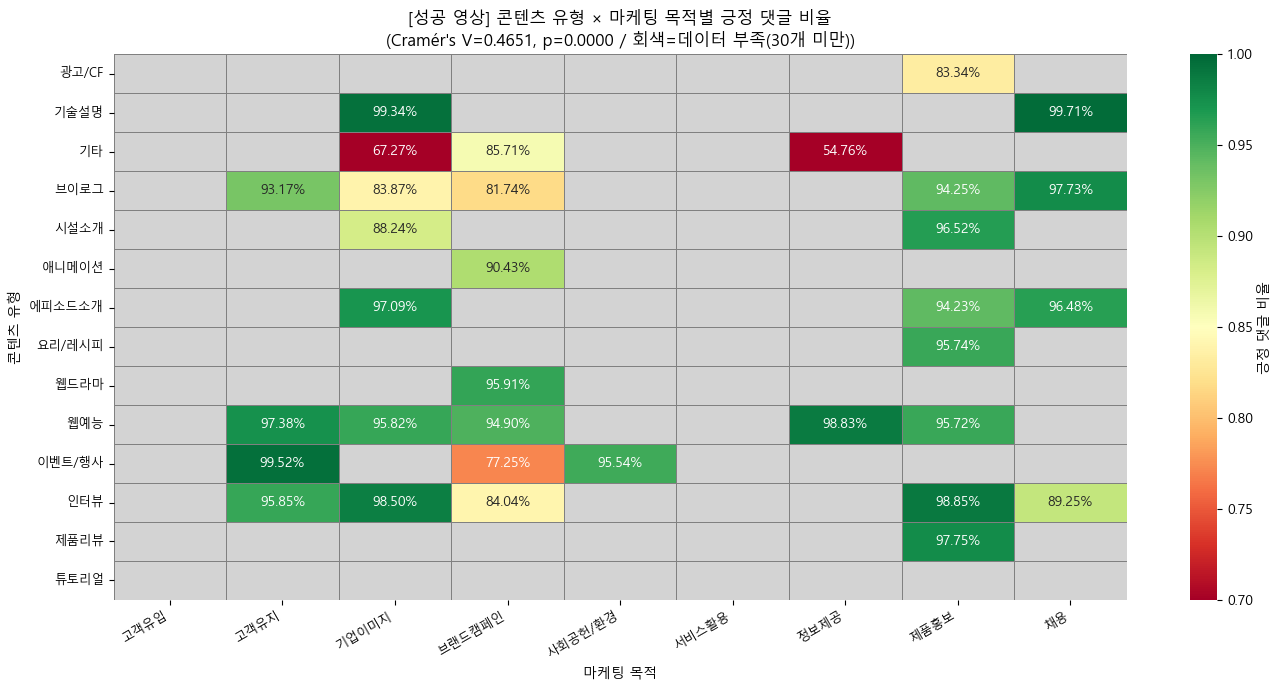

In [26]:
# 함수 실행
final_fnb_success_marketing = analyze_content_type_x_marketing_purpose(df_success, '성공')


[실패 영상] content_type × marketing_purpose 분석

[cls_marketing_purpose 분포]
cls_marketing_purpose
고객유지       1371
제품홍보        698
브랜드캠페인      487
사회공헌/환경      62
서비스활용        10
기업이미지         6
정보제공          2
Name: count, dtype: int64

[cls_content_type 분포]
cls_content_type
에피소드소개    672
웹예능       517
이벤트/행사    317
제품리뷰      275
브이로그      265
웹드라마      258
기타        203
애니메이션     110
광고/CF      14
요리/레시피      3
영양정보        2
Name: count, dtype: int64

=== (콘텐츠 유형 × 마케팅 목적)별 긍정 비율 ===


,cls_content_type,cls_marketing_purpose,positive_count,total,positive_ratio
0,광고/CF,제품홍보,9,14,0.642857
1,기타,고객유지,120,177,0.677966
2,기타,브랜드캠페인,6,17,0.352941
3,기타,제품홍보,9,9,1.000000
4,브이로그,고객유지,248,262,0.946565
5,브이로그,기업이미지,2,2,1.000000
6,브이로그,제품홍보,0,1,0.000000
7,애니메이션,고객유지,100,103,0.970874
8,애니메이션,서비스활용,5,7,0.714286
9,에피소드소개,고객유지,366,392,0.933673



=== 통계 검정 결과 ===
카이제곱 통계량 : 5543.7025
p-value         : 0.0000
자유도          : 60
Cramér's V      : 0.592
통계적 유의성   : 유의함 (p < 0.05)

=== 조합별 긍정률 테이블 (댓글 수 30개 미만 셀은 NaN) ===


cls_marketing_purpose,고객유지,기업이미지,브랜드캠페인,사회공헌/환경,서비스활용,정보제공,제품홍보
cls_content_type,,,,,,,
광고/CF,NaN,NaN,NaN,NaN,NaN,NaN,NaN
기타,0.6780,NaN,NaN,NaN,NaN,NaN,NaN
브이로그,0.9466,NaN,NaN,NaN,NaN,NaN,NaN
애니메이션,0.9709,NaN,NaN,NaN,NaN,NaN,NaN
에피소드소개,0.9337,NaN,0.9709,NaN,NaN,NaN,0.7965
영양정보,NaN,NaN,NaN,NaN,NaN,NaN,NaN
요리/레시피,NaN,NaN,NaN,NaN,NaN,NaN,NaN
웹드라마,0.8566,NaN,NaN,NaN,NaN,NaN,NaN
웹예능,0.7667,NaN,0.8944,NaN,NaN,NaN,0.8578


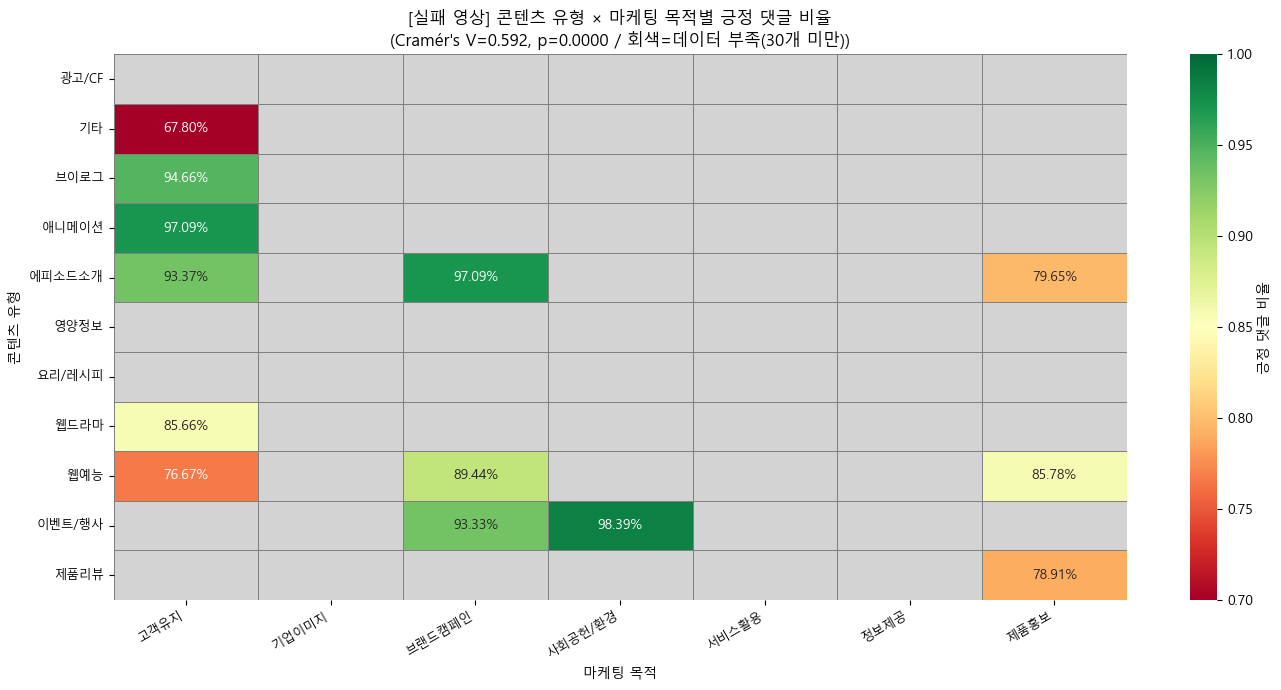

In [27]:
# 함수 실행
final_fnb_fail_marketing  = analyze_content_type_x_marketing_purpose(df_fail, '실패')